# **Analisis Data — Dataset Nutrisi Makanan Indonesia**

# Problem Statement

Perkembangan gaya hidup modern mendorong masyarakat untuk semakin memperhatikan pola konsumsi makanan sebagai bagian penting dalam menjaga kesehatan. Namun, masih banyak individu yang mengalami kesulitan dalam mengetahui kandungan nutrisi makanan yang mereka konsumsi, seperti jumlah kalori, protein, lemak, dan karbohidrat, terutama pada makanan sehari-hari yang disajikan tanpa label informasi gizi. Proses identifikasi kandungan nutrisi secara manual umumnya membutuhkan pencarian informasi melalui basis data nutrisi atau aplikasi tertentu yang mengharuskan pengguna memasukkan nama makanan secara spesifik. Kondisi ini menjadi kendala karena tidak semua pengguna mengetahui nama pasti makanan yang dikonsumsi, terlebih pada makanan lokal atau olahan khas daerah. Akibatnya, proses pemantauan asupan nutrisi menjadi kurang efektif dan dapat berdampak pada rendahnya kesadaran masyarakat dalam menjaga pola makan sehat.

Untuk mengatasi permasalahan tersebut, diperlukan sebuah solusi berbasis kecerdasan buatan yang mampu memprediksi kandungan nutrisi makanan secara otomatis melalui analisis citra makanan. Dengan memanfaatkan teknologi computer vision dan pendekatan transfer learning untuk mengekstraksi karakteristik visual makanan, sistem dapat mengenali kemiripan pola visual dari gambar yang diunggah pengguna dan mengestimasi nilai nutrisi berdasarkan data referensi yang tersedia. Solusi ini diharapkan mampu memberikan informasi nutrisi secara cepat, praktis, dan mudah diakses tanpa memerlukan input manual nama makanan. Implementasi sistem prediksi nutrisi berbasis gambar ini tidak hanya membantu pengguna dalam memonitor asupan gizi harian, tetapi juga mendukung peningkatan kesadaran masyarakat terhadap pentingnya pengelolaan pola makan sehat secara berbasis data.

# Pertanyaan Bisnis

1. Makanan apa yang memiliki kandungan protein tertinggi dalam dataset?
2. Makanan (*dish*) apa yang memiliki rasio protein terhadap kalori paling tinggi sebagai indikator efisiensi sumber protein?
3. Makanan apa yang memiliki kepadatan energi tertinggi berdasarkan jumlah kalori per gram makanan?
4. Zat gizi makro (protein, lemak, atau karbohidrat) mana yang memiliki koefisien korelasi terkuat dalam mempengaruhi total kalori makanan pada dataset?"
5. Apakah terdapat perbedaan profil nutrisi yang signifikan antara kategori makanan dish dan component?


# Setup Environment

In [1]:
# Mount Google Drive untuk akses dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Import library utama yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from difflib import SequenceMatcher

warnings.filterwarnings('ignore')

# Pengaturan visualisasi global
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

print("Library berhasil di-import.")

Library berhasil di-import.


# Data Wrangling

Data Wrangling adalah proses transformasi data dari bentuk mentah (*raw data*) menjadi format yang bersih, terstruktur, dan siap untuk digunakan dalam tahap analisis (*Exploratory Data Analysis*) maupun pemodelan Machine Learning.

## 1. Gathering Data

Gathering Data merupakan langkah awal yang krusial dalam siklus hidup data. Tahap ini berfokus pada pengumpulan dan pemuatan (*loading*) data mentah dari berbagai sumber eksternal ke dalam lingkungan komputasi (seperti Pandas Dataframe) untuk diproses lebih lanjut.

Dalam proyek analisis ini, mengintegrasikan dua sumber dataset nutrisi yang berbeda guna memperkaya variasi item makanan Indonesia:

1. **Dataset TKPI (Tabel Komposisi Pangan Indonesia):**
   * **Deskripsi:** Dataset institusional resmi yang dirilis oleh Kementerian Kesehatan Republik Indonesia. Dataset ini memuat profil nutrisi pangan murni, bahan mentah lokal, serta beberapa makanan olahan tradisional yang menjadi standar acuan ahli gizi di Indonesia.
   * **Karakteristik:** Memiliki kategorisasi kelompok makanan yang sangat detail (seperti sayuran, ikan, buah-buahan), namun format penulisan teks dan nama kolomnya memerlukan standardisasi ulang.

2. **Dataset Kaggle (Public/Community Dataset):**
   * **Deskripsi:** Dataset publik yang dikumpulkan dari berbagai platform pelacak kalori (*calorie tracker*) dan kontribusi komunitas pengguna di internet.
   * **Karakteristik:** Sangat kaya akan variasi makanan modern, makanan siap saji (*dish*), dan produk kuliner populer yang sering dikonsumsi masyarakat perkotaan saat ini.

In [3]:
# Path folder dataset di Google Drive
path_folder = '/content/drive/MyDrive/dataset_nutrisi/'

# Membaca dataset TKPI
df_tkpi   = pd.read_csv(path_folder + 'TKPI.csv')

# Membaca dataset Kaggle
df_kaggle = pd.read_csv(path_folder + 'Indonesian_Food_and_Drink_Nutrition_Dataset.csv')

print(f"df_tkpi   shape : {df_tkpi.shape}   → {df_tkpi.shape[0]} baris, {df_tkpi.shape[1]} kolom")
print(f"df_kaggle shape : {df_kaggle.shape}   → {df_kaggle.shape[0]} baris, {df_kaggle.shape[1]} kolom")

df_tkpi   shape : (1148, 28)   → 1148 baris, 28 kolom
df_kaggle shape : (1346, 7)   → 1346 baris, 7 kolom


## 2. Assessing Data

Assessing Data adalah proses audit atau pemeriksaan terhadap kualitas, kebersihan, dan integritas struktur dataset sebelum dilakukan tindakan manipulasi atau pembersihan. Langkah ini bertujuan untuk mengidentifikasi "penyakit" atau anomali pada data mentah agar kita dapat menentukan strategi pembersihan (*data cleaning*) yang tepat dan terukur.

Secara umum, proses penilaian data berfokus pada dua aspek utama:
1. Masalah Kualitas Data (Data Quality Issues): Berkaitan dengan isi data, seperti adanya nilai kosong (*missing values*), pencatatan data yang tidak akurat, atau data yang terduplikasi.
2. Masalah Struktur Data (Data Tidy Issues): Berkaitan dengan bentuk data, seperti tipe data kolom yang tidak sesuai (misalnya angka yang terbaca sebagai teks/string) atau struktur tabel yang menyulitkan analisis.

### Metodologi Pemeriksaan dalam Proyek Ini:

Pada tahap ini, enggunakan beberapa fungsi bawaan Pandas untuk menilai kedua dataset (`df_tkpi` dan `df_kaggle`) melalui beberpa tahapan:

* Pemeriksaan Skema & Tipe Data: Mengevaluasi jumlah baris dan kolom, memastikan kesesuaian tipe data (seperti memastikan kolom nutrisi bertipe numerik `float64` atau `int64`), serta melihat penggunaan memori.
* Identifikasi Data Kosong: Memetakan sebaran *missing values* pada kolom-kolom utama, khususnya pada zat gizi makro (protein, lemak, karbohidrat) yang menjadi pilar utama analisis.
* Deteksi Duplikasi : Mendeteksi adanya baris data yang berulang atau memiliki nama makanan yang sama persis (*exact duplicates*).
* Analisis Statistik Deskriptif: Meninjau sebaran statistik data (mean, median, min, max, kuartil) untuk mendeteksi adanya keanehan fisis, seperti nilai nutrisi negatif atau *outliers* ekstrem yang tidak logis secara ilmu gizi.


In [4]:
# Asesing Tipe Data
print("=" * 50)
print("df_tkpi — Tipe Data")
print("=" * 50)
print(df_tkpi.dtypes)
print()
print("=" * 50)
print("df_kaggle — Tipe Data")
print("=" * 50)
print(df_kaggle.dtypes)

df_tkpi — Tipe Data
No                         int64
Kode                      object
Nama Bahan Makanan        object
Air (g)                   object
Energi (Kal)               int64
Protein (g)               object
Lemak (g)                 object
Karbohidrat (g)           object
Serat (g)                 object
Abu (g)                   object
Kalsium/Ca (mg)           object
Fosfor/P (mg)             object
Besi/Fe (mg)              object
Natrium/Na (mg)           object
Kalium/Ka (mg)            object
Tembaga/Cu (mg)           object
Seng/Zn (mg)              object
Retinol/Vit.A (mcg)       object
Beta-karoten (mcg)        object
Karoten Total (mcg)       object
Thiamin/Vit.B1 (mg)       object
Riboflavin/Vit.B2 (mg)    object
Niasin (mg)               object
Vitamin C (mg)            object
BDD (%)                   object
Mentah/Olahan             object
Kelompok Makanan          object
Sumber TKPI 2019          object
dtype: object

df_kaggle — Tipe Data
id                i

Berdasarkan hasil pemeriksaan struktur dan tipe data pada kedua dataset, ditemukan inkonsistensi yang cukup signifikan antara `df_tkpi` dan `df_kaggle`:

1. Anomali pada `df_tkpi` (Angka Terbaca Sebagai Teks):
   * Hampir seluruh kolom zat gizi—termasuk kolom makronutrisi utama seperti `Protein (g)`, `Lemak (g)`, dan `Karbohidrat (g)`—memiliki tipe data **`object` (String/Teks)**. Kolom numerik yang murni hanyalah `Energi (Kal)`.
   * Hal ini terjadi karena adanya karakter non-numerik yang terselip di dalam baris data, seperti penggunaan tanda koma `,` sebagai pemisah desimal (bukan titik `.`), string kosong, tanda strip `-`, atau teks penanda tertentu.

2. **Kondisi `df_kaggle` (Sudah Ideal):**
   * Dataset dari Kaggle sudah memiliki struktur yang ideal. Kolom metrik nutrisi utama seperti `calories`, `proteins`, `fat`, dan `carbohydrate` sudah menggunakan tipe data numerik

> selanjutnya membersihkan karakter pengganggu (seperti mengubah koma `,` menjadi titik `.`, menangani teks *trace*), kemudian memaksa (*coerce*) perubahan tipe data kolom gizi utama pada `df_tkpi` menjadi `float64` menggunakan fungsi `pd.to_numeric()` agar selaras dengan `df_kaggle`.

In [5]:
# Konversi kolom TKPI yang menggunakan koma sebagai desimal
tkpi_num_cols = [
    'Protein (g)', 'Lemak (g)', 'Karbohidrat (g)',
    'Air (g)', 'Serat (g)', 'Abu (g)',
    'Kalsium/Ca (mg)', 'Fosfor/P (mg)', 'Besi/Fe (mg)',
    'Natrium/Na (mg)', 'Kalium/Ka (mg)',
    'Tembaga/Cu (mg)', 'Seng/Zn (mg)',
    'Retinol/Vit.A (mcg)', 'Beta-karoten (mcg)', 'Karoten Total (mcg)',
    'Thiamin/Vit.B1 (mg)', 'Riboflavin/Vit.B2 (mg)',
    'Niasin (mg)', 'Vitamin C (mg)', 'BDD (%)'
]
for col in tkpi_num_cols:
    if col in df_tkpi.columns:
        df_tkpi[col] = df_tkpi[col].astype(str).str.replace(',', '.', regex=False)
        df_tkpi[col] = pd.to_numeric(df_tkpi[col], errors='coerce')

print("=" * 50)
print("df_tkpi — Tipe Data")
print("=" * 50)
print(df_tkpi.dtypes)


df_tkpi — Tipe Data
No                          int64
Kode                       object
Nama Bahan Makanan         object
Air (g)                   float64
Energi (Kal)                int64
Protein (g)               float64
Lemak (g)                 float64
Karbohidrat (g)           float64
Serat (g)                 float64
Abu (g)                   float64
Kalsium/Ca (mg)           float64
Fosfor/P (mg)             float64
Besi/Fe (mg)              float64
Natrium/Na (mg)           float64
Kalium/Ka (mg)            float64
Tembaga/Cu (mg)           float64
Seng/Zn (mg)              float64
Retinol/Vit.A (mcg)       float64
Beta-karoten (mcg)        float64
Karoten Total (mcg)       float64
Thiamin/Vit.B1 (mg)       float64
Riboflavin/Vit.B2 (mg)    float64
Niasin (mg)               float64
Vitamin C (mg)            float64
BDD (%)                   float64
Mentah/Olahan              object
Kelompok Makanan           object
Sumber TKPI 2019           object
dtype: object


struktur tipe data pada `df_tkpi` kini telah berada dalam kondisi yang ideal dan siap dianalisis:

1. Keberhasilan Konversi Numerik (`float64`):
   * Seluruh kolom kadar zat gizi—mulai dari zat gizi makro (`Protein (g)`, `Lemak (g)`, `Karbohidrat (g)`) hingga zat gizi mikro (seperti `Kalsium/Ca (mg)`, `Vitamin C (mg)`, dsb) kini sudah bertipe data **`float64`** (numerik desimal).
   * Kolom `Energi (Kal)` dan `No` tetap mempertahankan tipe data murni **`int64`** (bilangan bulat).

2. **Konsistensi Fitur Kategorikal (`object`):**
   * Kolom non-numerik seperti `Nama Bahan Makanan`, `Mentah/Olahan`, dan `Kelompok Makanan` secara tepat tetap bertipe data **`object`** (teks/string).

In [6]:
# Missing Values

# Filter kolom spesifik pada TKPI sesuai kebutuhan analisis
kolom_target_tkpi = ['Nama Bahan Makanan', 'Energi (Kal)', 'Protein (g)', 'Lemak (g)', 'Karbohidrat (g)']

print("=" * 50)
print("df_tkpi — Missing Values (Kolom Utama)")
print("=" * 50)
kolom_ada = [col for col in kolom_target_tkpi if col in df_tkpi.columns]
mv_tkpi = df_tkpi[kolom_ada].isnull().sum()
print(mv_tkpi.to_string())

print()
print("=" * 50)
print("df_kaggle — Missing Values")
print("=" * 50)
mv_kaggle = df_kaggle.isnull().sum()
print(mv_kaggle[mv_kaggle > 0].to_string() if mv_kaggle.sum() > 0 else "Tidak ada missing values.")

df_tkpi — Missing Values (Kolom Utama)
Nama Bahan Makanan     0
Energi (Kal)           0
Protein (g)           11
Lemak (g)             11
Karbohidrat (g)       65

df_kaggle — Missing Values
Tidak ada missing values.


1. `df_tkpi` (Terdapat Data Hilang):
   * `Nama Bahan Makanan` & `Energi (Kal)`: 0 data kosong (Bersih).
   * `Protein (g)`: 11 kosong | `Lemak (g)`: 11 kosong | `Karbohidrat (g)`: 65 kosong.
   * Data hilang ini umumnya terjadi pada bahan pangan murni yang secara alami tidak mengandung zat gizi tertentu, sehingga pada dokumen acuan aslinya nilai tersebut dikosongkan.

2. `df_kaggle`:
   * 0 *missing value* pada seluruh kolom data.

In [7]:
# Duplikasi
dup_tkpi   = df_tkpi.duplicated().sum()
dup_kaggle = df_kaggle.duplicated().sum()
print(f"df_tkpi   — duplikat baris penuh : {dup_tkpi}")
print(f"df_kaggle — duplikat baris penuh : {dup_kaggle}")

df_tkpi   — duplikat baris penuh : 0
df_kaggle — duplikat baris penuh : 0


1. df_tkpi (Duplikat Baris Penuh):
   * Ditemukan 0 baris duplikat. Seluruh baris data bersifat unik dari segi kombinasi seluruh nilai kolomnya.

2. df_kaggle (Duplikat Baris Penuh):
   * Ditemukan 0 baris duplikat. Seluruh baris data bersifat unik secara keseluruhan.

> Meskipun tidak ada duplikasi baris penuh (keseluruhan kolom), tetap perlu mewaspadai adanya duplikasi parsial pada kolom nama_makanan, terutama variasi ejaan atau salah ketik (typo) yang memiliki nilai gizi sama. Penanganan duplikasi nama tersebut akan dieksekusi menggunakan pendekatan exact dan fuzzy matching pada tahap Cleaning Data.

In [8]:
# Statistik Deskriptif Kolom Kunci
numeric_cols_tkpi = ['Energi (Kal)', 'Protein (g)', 'Lemak (g)', 'Karbohidrat (g)']

print("=" * 50)
print("df_tkpi — Statistik Deskriptif (kolom nutrisi utama)")
print("=" * 50)
print(df_tkpi[numeric_cols_tkpi].describe().round(2))

print()
print("=" * 50)
print("df_kaggle — Statistik Deskriptif (kolom nutrisi utama)")
print("=" * 50)
print(df_kaggle[['calories', 'proteins', 'fat', 'carbohydrate']].describe().round(2))

df_tkpi — Statistik Deskriptif (kolom nutrisi utama)
       Energi (Kal)  Protein (g)  Lemak (g)  Karbohidrat (g)
count       1148.00      1137.00    1137.00          1083.00
mean         198.13         9.75       7.45            25.15
std          162.42        11.52      13.74            25.02
min            8.00         0.10       0.00             0.10
25%           73.75         1.80       0.50             5.70
50%          142.00         4.90       2.00            14.30
75%          320.00        14.50       8.20            37.75
max          902.00        74.30     100.00            94.00

df_kaggle — Statistik Deskriptif (kolom nutrisi utama)
       calories  proteins      fat  carbohydrate
count   1346.00   1346.00  1346.00       1346.00
mean     203.22     10.00     7.58         25.39
std      163.08     11.85    13.73         32.19
min        0.00      0.00     0.00          0.00
25%       75.00      1.80     0.50          4.53
50%      146.00      5.00     2.00         13.30

1. Distribusi Energi dan Kalori:
   * Nilai rata-rata energi pada df_tkpi berada di angka 198.13 Kal, sangat dekat dengan rata-rata df_kaggle sebesar 203.22 Kal.
   * Nilai median (50%) kedua dataset juga menunjukkan kemiripan, yaitu 142 Kal pada df_tkpi dan 146 Kal pada df_kaggle.
   * Batas atas energi maksimum berkisar antara 902 hingga 940 Kal per 100 gram bahan.

2. Sebaran Protein dan Lemak:
   * Kadar protein rata-rata berkisar di angka 9.75 gram (df_tkpi) dan 10.00 gram (df_kaggle), dengan nilai tertinggi mencapai 74.3 hingga 83.0 gram.
   * Komponen lemak memiliki karakteristik yang identik pada kedua dataset, dengan nilai median tepat di angka 2.00 gram dan nilai maksimum mencapai 100.00 gram (merepresentasikan produk minyak atau lemak murni).

3. Profil Karbohidrat:
   * Rata-rata kandungan karbohidrat menunjukkan konsistensi yang tinggi, yaitu 25.15 gram pada df_tkpi dan 25.39 gram pada df_kaggle.
   * Nilai kuartil ketiga (75%) di kedua dataset juga sangat seragam, berada pada kisaran 37.58 hingga 37.75 gram.

In [9]:
# Distribusi Kelompok Makanan (TKPI) & Unique Count (Kaggle)
print("df_tkpi — Kelompok Makanan (value counts):")
print(df_tkpi['Kelompok Makanan'].value_counts().to_string())
print()
print(f"df_kaggle — Jumlah makanan unik : {df_kaggle['name'].nunique()}")

df_tkpi — Kelompok Makanan (value counts):
Kelompok Makanan
Sayur       227
Ikan dsb    179
Kacang      138
Serealia    135
Buah        129
Daging      122
Umbi        109
Bumbu        37
Telur        18
Lemak        18
Gula         18
Susu         17
Minuman       1

df_kaggle — Jumlah makanan unik : 1346


1. Distribusi Kelompok Makanan pada df_tkpi:
   * Dataset df_tkpi memiliki sebaran kategori yang sangat bervariasi dengan total 13 kelompok makanan yang berbeda.
   * Komoditas nabati dan hasil laut mendominasi dataset ini, di mana kelompok Sayur menduduki posisi teratas dengan 227 item, diikuti oleh Ikan dsb (179 item), Kacang (138 item), Serealia (135 item), dan Buah (129 item).
   * Kelompok sumber protein hewani darat (Daging) serta sumber karbohidrat alternatif (Umbi) juga memiliki representasi yang kuat dengan masing-masing lebih dari 100 item.
   * Kelompok pendukung seperti Bumbu, Telur, Lemak, Gula, Susu, dan Minuman memiliki jumlah item yang jauh lebih sedikit, yang mana sangat logis karena variasi dasarnya memang lebih terbatas.

2. Karakteristik Data Unik pada df_kaggle:
   * Dataset df_kaggle tercatat memiliki 1.346 makanan yang bersifat unik secara nama dan entri.

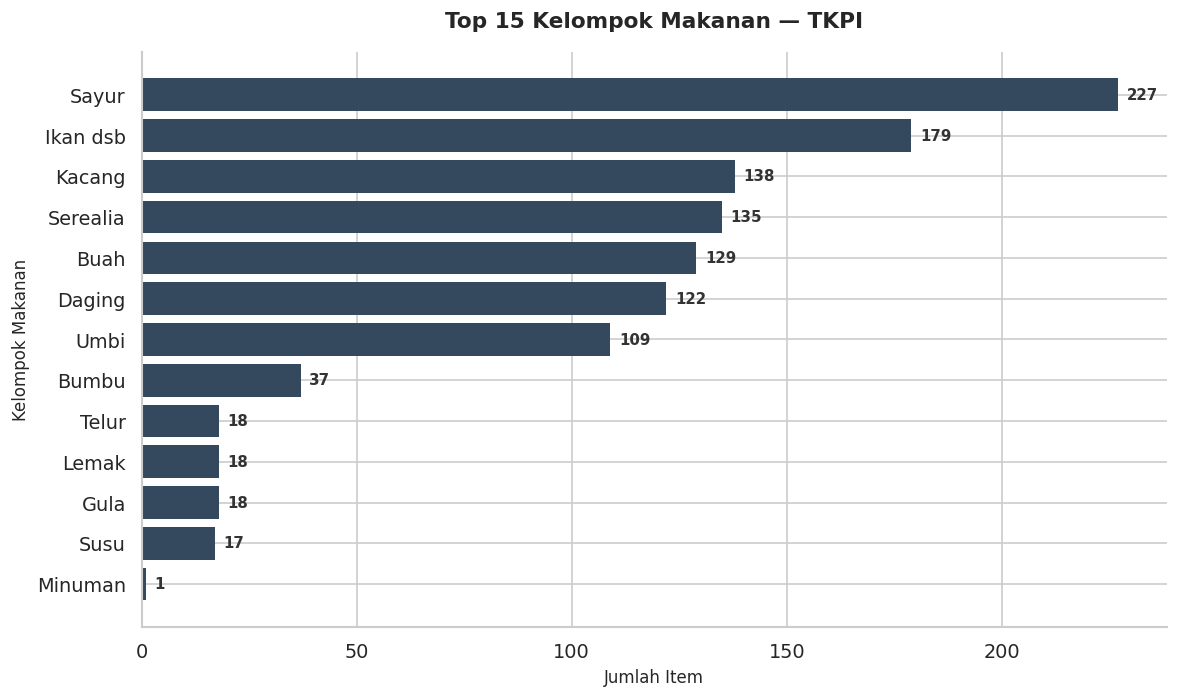

In [10]:
# Visualisasi Kelompok Makanan TKPI
grp_counts = df_tkpi['Kelompok Makanan'].value_counts().head(15)
grp_counts_plot = grp_counts.iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(grp_counts_plot.index, grp_counts_plot.values,
               color='#34495E', edgecolor='none')
for bar, val in zip(bars, grp_counts_plot.values):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9, fontweight='bold', color='#333333')

# Pengaturan anotasi dan kebersihan grafik
ax.set_title('Top 15 Kelompok Makanan — TKPI', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Jumlah Item', fontsize=10)
ax.set_ylabel('Kelompok Makanan', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Berdasarkan grafik batang horizontal di atas, dapat menganalisis variasi dan sebaran jumlah item data berdasarkan pengelompokan resmi dari Tabel Komposisi Pangan Indonesia (TKPI):

1. Dominasi Komoditas Nabati dan Bahari:
   * Kelompok Sayur menempati urutan pertama dengan jumlah item terbanyak, yaitu 227 makanan.
   * Posisi kedua diikuti erat oleh kelompok Ikan dsb (Ikan, Udang, Kerang, dll.) sebanyak 179 item, menunjukkan bahwa basis protein hewani laut memiliki representasi yang sangat kuat dalam dataset ini.

2. Sebaran Sumber Karbohidrat dan Protein Nabati:
   * Kelompok Kacang-kacangan (138 item) dan Serealia/biji-biji murni (135 item) memiliki jumlah yang relatif seimbang, disusul oleh kelompok Buah (129 item), Daging (122 item), dan Umbi-umbian (109 item).
   * Ketersediaan data yang merata di angka 100+ item untuk kelompok-kelompok ini menjamin keberagaman variasi zat gizi makro yang akan dieksplorasi.

3. Kelompok Pangan Pendukung:
   * Kelompok seperti Bumbu, Telur, Lemak, Gula, Susu, dan Minuman berada di posisi bawah dengan jumlah di bawah 40 item. Hal ini wajar karena variasi bahan dasar murni untuk kategori ini secara alami memang lebih terbatas dibandingkan variasi jenis sayur atau ikan di Indonesia.

## 3. Cleaning Data

Cleaning Data adalah salah satu tahapan dalam data wrangling yang bertujuan untuk memperbaiki, menyelaraskan, dan menyempurnakan kualitas dataset berdasarkan seluruh temuan masalah pada tahap Assessing Data. Pembersihan yang tepat akan memastikan bahwa data siap diolah secara komputasi tanpa menghasilkan galat atau bias dalam proses analisis.

* Normalisasi Teks secara Sistematis: Mengubah seluruh string nama makanan dan kategori menjadi huruf kecil (lowercase), menghapus karakter tanda baca yang mengganggu, membersihkan spasi di awal dan akhir kalimat (strip whitespace), serta menyatukan spasi ganda. Hal ini memastikan teks seragam secara format tanpa mengubah makna semantiknya.

* Imputasi Zat Gizi Makro: Mengisi baris-baris kosong (missing values) pada kolom protein, lemak, dan karbohidrat murni menggunakan Nilai 0 (Zero Imputation). Strategi ini dipilih untuk menjaga integritas ilmu gizi, karena bahan pangan tunggal tertentu secara alami memang tidak mengandung zat gizi makro lainnya.

* Klasifikasi Jenis Makanan (Feature Extraction): Mengekstraksi fitur baru bernama jenis_makanan untuk memisahkan entri data ke dalam dua kategori fungsional, yaitu dish (makanan jadi/siap konsumsi) dan komponen (bahan mentah/tunggal). Klasifikasi ini dilakukan melalui pendekatan pencocokan kata kunci pada teks nama makanan.

In [11]:
# Fungsi Normalisasi Teks
def clean_text(series):
    """Normalisasi teks: lowercase, hapus tanda baca, strip whitespace, gabungkan spasi ganda.
    Tidak mengubah makna semantik — hanya normalisasi format.
    """
    return (
        series
        .astype(str)
        .str.lower()
        .str.replace(r'[^\w\s]', '', regex=True)
        .str.strip()
        .str.replace(r'\s+', ' ', regex=True)
    )

# Cleaning TKPI
df_tkpi_clean = df_tkpi.copy()
df_tkpi_clean['Nama Bahan Makanan'] = clean_text(df_tkpi_clean['Nama Bahan Makanan'])
df_tkpi_clean['Kelompok Makanan']   = clean_text(df_tkpi_clean['Kelompok Makanan'])
df_tkpi_clean['Mentah/Olahan']      = clean_text(df_tkpi_clean['Mentah/Olahan'])

# Cleaning Kaggle
df_kaggle_clean = df_kaggle.copy()
df_kaggle_clean['name'] = clean_text(df_kaggle_clean['name'])

print("Cleaning selesai.")
print(f"   df_tkpi_clean   : {df_tkpi_clean.shape}")
print(f"   df_kaggle_clean : {df_kaggle_clean.shape}")

Cleaning selesai.
   df_tkpi_clean   : (1148, 28)
   df_kaggle_clean : (1346, 7)


Setelah fungsi clean_text dieksekusi pada kolom teks target di kedua dataset, berikut adalah hasil dari tahapan pembersihan awal ini:

1. Standardisasi Teks Berhasil:
   * Seluruh string pada kolom Nama Bahan Makanan, Kelompok Makanan, dan Mentah/Olahan di df_tkpi_clean, serta kolom name di df_kaggle_clean telah berhasil diseragamkan ke dalam format huruf kecil (lowercase).
   * Karakter tanda baca yang berpotensi mengganggu proses pencocokan string telah dihapus sepenuhnya, dan seluruh spasi ganda atau spasi di ujung kalimat (whitespace) telah dirapikan.

2. Integritas Dimensi Dataset Terjaga:
   * Jumlah baris pada df_tkpi_clean tetap utuh sebanyak 1,148 baris dengan 28 kolom.
   * Jumlah baris pada df_kaggle_clean tetap konsisten sebanyak 1,346 baris dengan 7 kolom.
   * Tidak ada baris data yang terbuang atau hilang selama proses normalisasi format teks ini berlangsung.

In [12]:
# Penanganan Missing Value pada Zat Gizi Makro
# Tentukan kolom-kolom nutrisi makro yang memiliki missing value
kolom_nutrisi_tkpi = ['Karbohidrat (g)', 'Protein (g)', 'Lemak (g)']


# Eksekusi Imputasi Nilai 0 (Fillna with 0)
for col in kolom_nutrisi_tkpi:
    if col in df_tkpi_clean.columns:
        df_tkpi_clean[col] = df_tkpi_clean[col].fillna(0.0)

print("Imputasi Selesai: Semua missing value makronutrisi telah diisi dengan nilai 0.0")

# Cek ulang untuk memastikan tidak ada lagi missing value
print("\nJumlah Missing Value SETELAH Imputasi:")
print(f"   Total missing di df_tkpi_clean   : {df_tkpi_clean[kolom_nutrisi_tkpi].isna().sum().sum()}")

Imputasi Selesai: Semua missing value makronutrisi telah diisi dengan nilai 0.0

Jumlah Missing Value SETELAH Imputasi:
   Total missing di df_tkpi_clean   : 0


Setelah dilakukan proses penanganan data hilang pada tahap pembersihan, berikut adalah hasil akhir dari pengecekan kondisi data:

1. Keberhasilan Imputasi Nilai 0.0:
   * Seluruh missing value pada kolom zat gizi makro (protein, lemak, dan karbohidrat) berhasil diisi menggunakan Nilai 0 (Zero Imputation).
   * Pengisian ini berhasil mempertahankan integritas dan logika biologis dari bahan pangan tunggal yang secara alami murni hanya membawa satu unsur zat gizi makro tertentu.

2. Status Kebersihan Dataset:
   * Total missing value pada df_tkpi_clean kini telah menyusut menjadi tepat 0.

In [13]:
# Klasifikasi Jenis Makanan — TKPI
# Logika:
# - Kelompok bumbu/lemak/gula/minuman → komponen
# - Kolom Mentah/Olahan == 'tunggal' → komponen
# - Nama mengandung kata kunci bahan mentah → komponen
# - Lainnya → dish

komponen_groups_tkpi = {'bumbu', 'lemak', 'gula', 'minuman'}

def jenis_tkpi(row):
    grp   = str(row['Kelompok Makanan']).lower().strip()
    state = str(row['Mentah/Olahan']).lower().strip()

    if grp in komponen_groups_tkpi:
        return 'komponen'
    if state == 'tunggal':
        return 'komponen'

    name = str(row['Nama Bahan Makanan']).lower()
    komponen_keywords = [
        'tepung', 'minyak', 'mentega', 'margarin', 'santan', 'kecap',
        'saos', 'petis', 'terasi', 'cuka', 'gula', 'selai', 'jam',
        'madu', 'kopi', 'teh', 'sirup', 'susu', 'yoghurt', 'keju',
        'sari kedelai', 'abon', 'dendeng mentah', 'kering mentah',
        'asap mentah', 'asin mentah', 'pindang', 'teri kering',
        'teri bubuk', 'teri tepung', 'ikan tepung', 'ikan asin kering',
        'bekasam', 'bekasang', 'tauco', 'bungkil', 'ampas', 'katul',
        'rusip', 'tempoya',
    ]
    for kw in komponen_keywords:
        if kw in name:
            return 'komponen'
    return 'dish'

df_tkpi_clean['jenis_makanan'] = df_tkpi_clean.apply(jenis_tkpi, axis=1)
print("Distribusi jenis_makanan — TKPI:")
print(df_tkpi_clean['jenis_makanan'].value_counts())

Distribusi jenis_makanan — TKPI:
jenis_makanan
komponen    691
dish        457
Name: count, dtype: int64


Berdasarkan hasil proses ekstraksi fitur dan klasifikasi teks pada dataset df_tkpi, berikut adalah sebaran jumlah item makanan yang berhasil dikategorikan:

1. Kategori Komponen (691 item):
   * Kategori komponen mendominasi dataset TKPI secara signifikan.
   * Hasil ini sangat akurat secara konsteks, karena peran utama dari dokumen resmi pemerintah (Tabel Komposisi Pangan Indonesia) adalah mencatat profil nutrisi bahan pangan murni, mentah, atau tunggal yang ada di ekosistem pangan lokal.

2. Kategori Dish (457 item):
   * Sebanyak 457 item berhasil diidentifikasi sebagai dish atau makanan olahan siap konsumsi.
   * Ketersediaan ratusan item kategori dish ini menunjukkan bahwa dataset TKPI tidak hanya berisi bahan mentah murni, tetapi juga mencakup ragam masakan tradisional khas Indonesia yang siap dikonsumsi.

In [14]:
# Klasifikasi Jenis Makanan — Kaggle
# Logika:
# - Cek keyword 'komponen' dulu (bahan mentah)
# - Jika mengandung keyword 'dish', override ke dish
# - Lainnya default → komponen

dish_keywords_kaggle = [
    'goreng', 'rebus', 'kukus', 'bakar', 'tumis', 'masakan', 'masak',
    'pepes', 'presto', 'asam manis', 'balado', 'gulai', 'rendang',
    'soto', 'sop ', 'rawon', 'gado-gado', 'ketoprak', 'bakso',
    'bakwan', 'nasi goreng', 'nasi uduk', 'nasi rames', 'nasi tim',
    'nasi gemuk', 'nasi gurih', 'nasi minyak', 'nasi jagung', 'nasi beras merah',
    'mie goreng', 'mie ayam', 'mie bakso', 'mie aceh', 'mie celon',
    'mie pangsit', 'bihun goreng', 'laksa', 'tekwan', 'pempek',
    'martabak', 'siomay', 'pastel', 'risoles', 'combro', 'misro',
    'tahu goreng', 'tahu telur', 'tempe goreng', 'tempe sayur',
    'oncom goreng', 'oncom pepes', 'oncom merah sayur', 'oncom kacang tanah pepes',
    'sayur asem', 'sayur sop', 'cap cai', 'karedok', 'asinan',
    'rujak', 'semur', 'gado', 'ketoprak', 'anyang',
    'empal goreng', 'ayam goreng', 'ayam taliwang',
    'bebek goreng', 'bebek daging goreng',
    'gulai ikan', 'gulai kambing', 'gulai tiram', 'gulai pakis',
    'ikan bandeng presto', 'ikan mas goreng', 'ikan mas pepes',
    'ikan mujair goreng', 'ikan mujair pepes', 'ikan lele goreng',
    'ikan baung bakar', 'ikan belida bakar', 'ikan patin bakar',
    'ikan papuyu bakar', 'ikan lais bakar',
    'cumi-cumi goreng', 'belut goreng',
    'beef burger', 'beef teriyaki', 'beef yakiniku',
    'chicken teriyaki', 'bulgogi', 'sukiyaki',
    'coto mangkasara', 'sate ', 'soto ', 'rawon',
    'rendang sapi', 'brongkos', 'gudeg',
    'dodol', 'kue ', 'onde-onde', 'lupis', 'ongol', 'lapis legit',
    'bika ambon', 'wingko', 'wajit', 'geplak', 'jenang',
    'getuk goreng', 'getuk lindri', 'getuk pisang',
    'singkong goreng', 'singkong kukus', 'singkong tape',
    'ubi jalar goreng', 'ubi jalar rebus',
    'pisang goreng', 'jagung rebus',
    'bubur ', 'papeda', 'kapurung',
    'ketupat', 'leupeut', 'lemper', 'lapis', 'onde',
    'putu mayang', 'kelepon', 'lupis ketan',
    'tapai', 'tape',
    'pindang ikan', 'ikan pindang',
    'kalio ', 'sop buntut', 'sop daging', 'sop kaki', 'sop kambing', 'sop konro',
    'teri balado',
    'toge goreng', 'taoge goreng', 'toge seduh',
    'keripik bayam', 'keripik kentang', 'keripik singkong', 'keripik tempe', 'keripik ubi',
    'kerupuk udang goreng', 'kerupuk melinjo',
    'emping',
    'jamu', 'bir ', 'es krim', 'es mambo', 'es sirup',
    'intip goreng', 'brondong',
    'corned beef', 'ham ', 'sosis', 'worst',
    'sardines dalam kaleng',
    'abon ikan', 'abon haruwan',
    'bacang', 'buras', 'pundut nasi',
    'nasi', 'bubur tinotuan', 'mie ',
    'tumis bayam', 'bayam tumis',
    'daun singkong rebus', 'daun singkong lodeh', 'daun singkong ',
    'kangkung tumis', 'pelecing kangkung',
    'gambas lodeh', 'pepaya lodeh',
    'terong kukus', 'terong + oncom',
    'wortel kukus', 'wortel rebus',
    'bayam kukus', 'bayam rebus',
    'buncis rebus', 'buncis asam',
    'kangkung kukus', 'kangkung rebus',
]

komponen_keywords_kaggle = [
    'segar', 'mentah', 'kering', 'tepung', 'minyak', 'mentega', 'margarin',
    'santan', 'kecap', 'saos', 'petis', 'terasi', 'cuka', 'gula', 'selai', 'jam',
    'madu', 'kopi', 'teh', 'sirup', 'susu', 'yoghurt', 'keju',
    'bekasam', 'bekasang', 'tauco', 'bungkil', 'ampas', 'katul',
    'rusip', 'tempoya', 'ragi', 'gelatine',
    'beras ', 'biji ', 'bungkil', 'pati ',
    'bubuk', 'instant', 'instan',
    'dendeng mentah', 'asin mentah', 'asap mentah', 'kering mentah',
]

def jenis_kaggle(name):
    n = str(name).lower().strip()
    for kw in komponen_keywords_kaggle:
        if kw in n:
            for dk in dish_keywords_kaggle:
                if dk in n:
                    return 'dish'
            return 'komponen'
    for dk in dish_keywords_kaggle:
        if dk in n:
            return 'dish'
    return 'komponen'

df_kaggle_clean['jenis_makanan'] = df_kaggle_clean['name'].apply(jenis_kaggle)
print("Distribusi jenis_makanan — Kaggle:")
print(df_kaggle_clean['jenis_makanan'].value_counts())

Distribusi jenis_makanan — Kaggle:
jenis_makanan
komponen    940
dish        406
Name: count, dtype: int64


Berdasarkan hasil proses ekstraksi fitur dan klasifikasi teks pada dataset df_kaggle, berikut adalah sebaran jumlah item makanan yang berhasil dikategorikan:

1. Kategori Komponen (940 item):
   * Sebanyak 940 item diidentifikasi sebagai komponen atau bahan makanan murni/tunggal.
   * Jumlah yang besar ini sangat menguntungkan karena memberikan variasi basis bahan mentah yang sangat kaya untuk melengkapi pustaka komponen gizi yang sudah ada.

2. Kategori Dish (406 item):
   * Sebanyak 406 item berhasil dikategorikan sebagai dish atau makanan olahan siap konsumsi.
   * Ketersediaan ratusan item makanan siap saji ini akan memperkuat keberagaman variasi menu kuliner modern yang biasanya jarang tercakup dalam tabel pangan institusional murni.

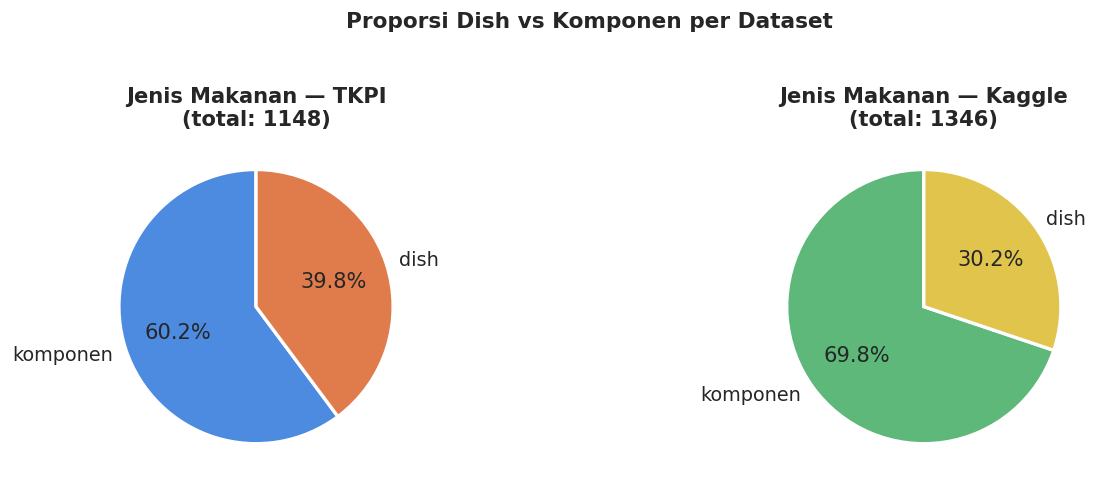

In [15]:
# Visualisasi Distribusi Jenis Makanan
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, df, title, colors in zip(
    axes,
    [df_tkpi_clean, df_kaggle_clean],
    ['TKPI', 'Kaggle'],
    [['#4C8BE0', '#E07C4C'], ['#5DB87A', '#E0C44C']]
):
    counts = df['jenis_makanan'].value_counts()
    wedges, texts, autotexts = ax.pie(
        counts.values,
        labels=counts.index,
        autopct='%1.1f%%',
        colors=colors,
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2}
    )
    ax.set_title(f'Jenis Makanan — {title}\n(total: {len(df)})', fontweight='bold')

plt.suptitle('Proporsi Dish vs Komponen per Dataset', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Ringkasan Analisis Perbandingan Proporsi Jenis Makanan

Berdasarkan grafik pai (pie chart) di atas, kita dapat mengevaluasi perbandingan komposisi jenis_makanan antara dataset df_tkpi_clean dan df_kaggle_clean setelah melewati tahap klasifikasi teks:

1. Dominasi Kategori Komponen di Kedua Dataset:
   * Kedua dataset menunjukkan tren yang serupa, di mana kategori komponen (bahan makanan tunggal/mentah) mendominasi sebagian besar isi data.
   * Pada dataset TKPI, komponen menyumbang porsi sebesar 60.2%, sementara pada dataset Kaggle angkanya jauh lebih tinggi mencapai 69.8%.

2. Proporsi Menu Olahan (Dish):
   * Dataset TKPI memiliki proporsi dish sebesar 39.8% dari total 1,148 baris data. Hal ini menunjukkan bahwa pustaka pangan pemerintah menyertakan cukup banyak variasi masakan tradisional siap konsumsi.
   * Dataset Kaggle memiliki proporsi dish sebesar 30.2% dari total 1,346 baris data.

## 4. Merging & Standardisasi Skema

## 4. Merging & Standardisasi Skema (Penggabungan & Penyelarasan Data)

Tahap Merging dan Standardisasi Skema dilakukan setelah kedua dataset (df_tkpi_clean dan df_kaggle_clean) berada dalam kondisi bersih dan memiliki tipe data yang valid. Proses ini bertujuan untuk menyatukan dua sumber data yang berbeda ke dalam satu struktur tabel yang seragam (single source of truth) agar dapat dianalisis secara komprehensif pada tahap EDA.

* Pemetaan Nama Kolom (Column Mapping): Menyelaraskan nama-nama fitur utama antara kedua dataset agar memiliki nama yang identik. Kolom gizi pada df_tkpi (seperti Protein (g), Lemak (g), Karbohidrat (g)) dan df_kaggle (seperti proteins, fat, carbohydrate) dipetakan ke dalam nama kolom baru yang seragam, yaitu: kalori, protein, lemak, dan karbohidrat.

* Penggabungan Tabel (Concatenation): Menyatukan kedua dataframe secara vertikal menggunakan fungsi pd.concat(). Langkah ini menghasilkan satu dataset besar bernama df_merged yang menampung seluruh baris dari pustaka pangan pemerintah dan data komunitas publik.

In [16]:
# Standardisasi Kolom TKPI
df_tkpi_std = df_tkpi_clean.rename(columns={
    'Nama Bahan Makanan': 'nama_makanan',
    'Energi (Kal)':       'kalori',
    'Protein (g)':        'protein',
    'Lemak (g)':          'lemak',
    'Karbohidrat (g)':    'karbohidrat',
})[['nama_makanan', 'jenis_makanan', 'kalori', 'protein', 'lemak', 'karbohidrat']]
df_tkpi_std['source'] = 'tkpi'

# Standardisasi Kolom Kaggle
df_kaggle_std = df_kaggle_clean.rename(columns={
    'name':         'nama_makanan',
    'calories':     'kalori',
    'proteins':     'protein',
    'fat':          'lemak',
    'carbohydrate': 'karbohidrat',
})[['nama_makanan', 'jenis_makanan', 'kalori', 'protein', 'lemak', 'karbohidrat']]
df_kaggle_std['source'] = 'kaggle'

# Gabungkan kedua dataset
df_merged = pd.concat([df_tkpi_std, df_kaggle_std], ignore_index=True)
df_merged['id'] = range(1, len(df_merged) + 1)
df_merged = df_merged[['id', 'jenis_makanan', 'nama_makanan',
                        'kalori', 'protein', 'lemak', 'karbohidrat', 'source']]

print(f"df_merged shape : {df_merged.shape}")
print(f"Total rows      : {len(df_merged)}")
df_merged.head(10)

df_merged shape : (2494, 8)
Total rows      : 2494


,id,jenis_makanan,nama_makanan,kalori,protein,lemak,karbohidrat,source
0,1,komponen,blewah segar,34.0,0.8,0.2,8.2,tkpi
1,2,komponen,mentimun suri segar,16.0,1.3,0.0,2.1,tkpi
2,3,dish,nasi tim,120.0,2.4,0.4,26.0,tkpi
3,4,komponen,akar tonjong segar,45.0,1.1,0.4,10.8,tkpi
4,5,komponen,aletoge segar,37.0,4.4,0.5,3.8,tkpi
5,6,komponen,andaliman segar,99.0,4.6,1.0,18.0,tkpi
6,7,dish,ayam goreng pasundan dada,246.0,37.9,9.0,0.7,tkpi
7,8,dish,ayam goreng pasundan paha,245.0,33.1,11.4,0.3,tkpi
8,9,dish,ayam goreng pioneer dada,295.0,37.4,14.7,0.6,tkpi
9,10,dish,ayam goreng sukabumi dada,244.0,36.7,9.2,1.0,tkpi


Setelah proses standardisasi skema dan penyelarasan nama kolom selesai dilakukan, kedua dataset (df_tkpi_clean dan df_kaggle_clean) digabungkan secara vertikal

1. Integritas Dimensi dan Konsolidasi Baris:
   * Dataset gabungan bernama df_merged berhasil terbentuk dengan total dimensi sebanyak 2.494 baris dan 8 kolom utama.
   * Jumlah total 2.494 baris ini merupakan akumulasi presisi yang sempurna dari penggabungan 1.148 baris data milik df_tkpi_clean dan 1.346 baris data milik df_kaggle_clean.

2. Struktur Skema Kolom yang Seragam:
   * Seluruh entri kini telah bersatu di bawah struktur kolom gizi makro yang seragam, yaitu id, jenis_makanan, nama_makanan, kalori, protein, lemak, karbohidrat, dan source.
   * Kolom source berfungsi dengan baik sebagai penanda rekam jejak digital untuk membedakan asal-usul data (bernilai 'tkpi' atau 'kaggle') pasca-penggabungan.

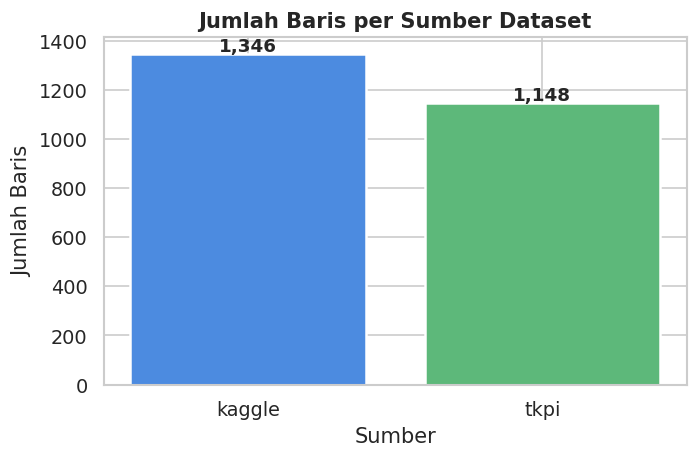

In [17]:
# Visualisasi Komposisi Sumber Data
src_counts = df_merged['source'].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(src_counts.index, src_counts.values,
              color=['#4C8BE0', '#5DB87A'], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, src_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{val:,}', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Jumlah Baris per Sumber Dataset', fontweight='bold')
ax.set_ylabel('Jumlah Baris')
ax.set_xlabel('Sumber')
plt.tight_layout()
plt.show()

Berdasarkan grafik batang (bar chart) di atas

1. Kontribusi Dataset Kaggle:
   * Dataset dari platform komunitas Kaggle menyumbangkan jumlah baris terbesar, yaitu sebanyak 1.346 entri makanan.
   * Tingginya volume data ini memberikan fondasi yang kuat bagi variasi menu masakan modern dan produk komersial yang beredar luas di masyarakat.

2. Kontribusi Dataset TKPI:
   * Pustaka pangan resmi pemerintah (TKPI) menyumbangkan sebanyak 1.148 entri data pangan lokal.
   * Kontribusi ini menjamin kelengkapan data gizi dasar untuk bahan pangan murni, mentah, dan hidangan tradisional khas nusantara yang menjadi acuan standar gizi nasional.


## 5. df_food — Deduplikasi & Feature Engineering (Cleaning Lanjutan & Rekayasa Fitur)

Tahap Deduplikasi Lanjutan dan Feature Engineering merupakan langkah final sebelum dataset memasuki proses analisis eksploratif (EDA). Pada tahap ini, kita membentuk dataframe baru bernama df_food yang ditargetkan menjadi dataset tunggal yang benar-benar bersih, unik, dan kaya akan metrik analisis baru.

* Pembersihan Duplikasi Parsial (Fuzzy Deduplication): Mengidentifikasi dan mengeliminasi nama makanan yang serupa akibat variasi ejaan atau kesalahan ketik (typo) namun memiliki nilai kandungan gizi yang identik (misalnya kasus mujahir vs mujair). Penyaringan dilakukan menggunakan kombinasi metode exact matching dan fuzzy string matching berbasis nilai kemiripan teks (similarity ratio) untuk memastikan tidak ada redundansi data gizi yang sama.

* Rekayasa Fitur Turunan (Feature Engineering): Membuat indikator dan metrik baru dari kombinasi zat gizi makro yang sudah ada guna mempermudah penarikan kesimpulan bisnis. Beberapa fitur rasio turunan yang ditambahkan meliputi:
  * protein_per_calorie: Rasio kandungan protein terhadap total energi untuk mengukur efisiensi densitas protein suatu makanan.
  * fat_per_calorie: Rasio kandungan lemak terhadap kalori untuk memetakan densitas lemak.
  * carb_per_calorie: Rasio kandungan karbohidrat terhadap kalori untuk memetakan densitas karbohidrat.
  * protein_fat_ratio: Perbandingan langsung kadar protein terhadap lemak untuk menyaring makanan tinggi protein rendah lemak.
  * macro_balance_score: Skor kalkulasi untuk mengukur tingkat keseimbangan dan proporsi distribusi energi dari ketiga zat gizi makro pada setiap makanan.

> Menghasilkan dataset final df_food.csv yang steril dari segala bentuk duplikasi nama dan kaya akan dimensi informasi gizi yang baru. Dataset ini akan menjadi pondasi utama yang digunakan untuk menjawab seluruh pertanyaan bisnis pada tahap Exploratory Data Analysis (EDA) serta menentukan kelas final klasifikasi gambar.

In [18]:
# Buat df_food dari df_merged
df_food = df_merged.copy()
print(f"df_food awal   : {df_food.shape}")
print(df_food.dtypes)

df_food awal   : (2494, 8)
id                 int64
jenis_makanan     object
nama_makanan      object
kalori           float64
protein          float64
lemak            float64
karbohidrat      float64
source            object
dtype: object


Sebelum melangkah ke tahap deduplikasi parsial dan rekayasa fitur, dataframe df_food berhasil diinisialisasi sebagai salinan (copy) penuh dari df_merged. Berikut adalah peninjauan strukturnya:

1. Volume Data Awal:
   * Dataset df_food memulai tahapan ini dengan total dimensi awal sebanyak 2.494 baris dan 8 kolom utama.
   * Jumlah baris ini masih utuh karena proses penyaringan kemiripan teks (fuzzy deduplication) belum dieksekusi.

2. Validitas Tipe Data:
   * Struktur tipe data pada setiap kolom sudah berada dalam kondisi yang sepenuhnya valid dan konsisten.
   * Seluruh fitur metrik gizi utama—yaitu kalori, protein, lemak, dan karbohidrat—telah seragam bertipe data float64 (numerik desimal).
   * Kolom identifikator seperti id (int64) serta kolom kategorikal seperti jenis_makanan, nama_makanan, dan source tetap mempertahankan tipe data object (teks).

In [19]:
# Cek dan hapus duplikat berdasarkan nama_makanan & nilai nutrisi (Fuzzy Matching)

def apakah_mirip(str1, str2, threshold=0.9):
    """Menghitung rasio kemiripan antara dua teks"""
    return SequenceMatcher(None, str1, str2).ratio() >= threshold

n_dup_exact = df_food.duplicated(subset=['nama_makanan']).sum()
print(f"Duplikat nama_makanan (Exact Match) sebelum deduplikasi: {n_dup_exact}")

# Hapus duplikat yang benar-benar sama persis
df_food.drop_duplicates(subset=['nama_makanan'], inplace=True)
df_food.reset_index(drop=True, inplace=True)

# Proses Fuzzy Deduplication untuk nama yang mirip dengan nutrisi yang identik
kolom_nutrisi = ['kalori', 'protein', 'lemak', 'karbohidrat']
indeks_dihapus = []

# Lakukan pengecekan
for i in range(len(df_food)):
    if i in indeks_dihapus:
        continue

    for j in range(i + 1, len(df_food)):
        if j in indeks_dihapus:
            continue

        # Cek apakah nilai nutrisinya sama persis
        nutrisi_sama = df_food.loc[i, kolom_nutrisi].equals(df_food.loc[j, kolom_nutrisi])

        if nutrisi_sama:
            # Jika nutrisi sama, cek seberapa mirip nama makanannya (Threshold 85% - 90%)
            nama1 = df_food.loc[i, 'nama_makanan']
            nama2 = df_food.loc[j, 'nama_makanan']

            if apakah_mirip(nama1, nama2, threshold=0.88):
                print(f"Mendeteksi kemiripan: '{nama1}' dengan '{nama2}' (Nutrisi sama). Menyimpan '{nama1}'")
                indeks_dihapus.append(j)

# Hapus baris berbasis fuzzy matching yang sudah diidentifikasi
df_food.drop(index=indeks_dihapus, inplace=True)
df_food.reset_index(drop=True, inplace=True)

print(f"\nJumlah baris dihapus melalui Fuzzy Matching: {len(indeks_dihapus)}")
print(f"df_food setelah deduplikasi final: {df_food.shape}")

Duplikat nama_makanan (Exact Match) sebelum deduplikasi: 840
Mendeteksi kemiripan: 'daun talas rebus' dengan 'daun tales rebus' (Nutrisi sama). Menyimpan 'daun talas rebus'
Mendeteksi kemiripan: 'taoge seduh' dengan 'toge seduh' (Nutrisi sama). Menyimpan 'taoge seduh'
Mendeteksi kemiripan: 'kacang tolo tunggak rebus' dengan 'kacang tunggak rebus' (Nutrisi sama). Menyimpan 'kacang tolo tunggak rebus'
Mendeteksi kemiripan: 'asam kandis kering' dengan 'asan kandis kering' (Nutrisi sama). Menyimpan 'asam kandis kering'
Mendeteksi kemiripan: 'ayam goreng church texas sayap' dengan 'ayam goreng church texa sayap' (Nutrisi sama). Menyimpan 'ayam goreng church texas sayap'
Mendeteksi kemiripan: 'ikan mujahir goreng' dengan 'ikan mujair goreng' (Nutrisi sama). Menyimpan 'ikan mujahir goreng'
Mendeteksi kemiripan: 'ikan mujahir pepes' dengan 'ikan mujair pepes' (Nutrisi sama). Menyimpan 'ikan mujahir pepes'
Mendeteksi kemiripan: 'ikan mujahir dendeng mentah' dengan 'ikan mujair dendeng mentah' (

Tahap pembersihan redundansi data dilakukan secara berlapis untuk menyaring entri makanan yang berulang. Berikut adalah hasil dari proses deduplikasi tersebut:

1. Penyaringan Duplikat Mutlak (Exact Match):
   * Terdeteksi sebanyak 840 entri nama_makanan yang memiliki kecocokan teks yang sama persis (exact match).
   * Seluruh baris duplikat mutlak ini langsung dieliminasi secara otomatis untuk mencegah bias data gizi yang berulang.

2. Pembersihan Variasi Ejaan dan Typo (Fuzzy Matching):
   * Sistem berbasis fuzzy string matching berhasil mengidentifikasi variasi ejaan, singkatan, dan kesalahan pengetikan (typo) pada nama makanan yang terbukti memiliki profil kandungan nutrisi yang sama.
   * Sebanyak 20 baris berhasil disaring dari deteksi kemiripan teks ini. Contoh keberhasilan penyaringan meliputi koreksi typo/vokal (tales vs talas, toge vs taoge), penyelarasan variasi nama lokal (mujair vs mujahir), perbaikan spasi ganda (merah banda vs merahbanda), hingga standarisasi singkatan (dg kulit vs berkulit).

3. Dimensi Akhir Dataset Final (df_food):
   * Setelah seluruh rangkaian deduplikasi (exact dan fuzzy) selesai dieksekusi, ukuran dataset menyusut dari 2.494 baris menjadi tepat 1.634 baris unik dengan 8 kolom utama.

> Proses deduplikasi berlapis ini sangat krusial karena berhasil membuang ratusan data redundan tanpa kehilangan informasi pangan yang unik. Pengurangan dimensi data ini membuat df_food menjadi sangat steril, efisien, dan memiliki kualitas integritas tinggi, sehingga siap digunakan sebagai representasi kelas objek untuk tahap analisis eksploratif (EDA) selanjutnya.

In [20]:
# Feature Engineering
# Fitur-fitur ini berguna sebagai input tambahan ke model ML dan untuk analisis nutrisi.

df_food['kalori']      = pd.to_numeric(df_food['kalori'],      errors='coerce')
df_food['protein']     = pd.to_numeric(df_food['protein'],     errors='coerce')
df_food['lemak']       = pd.to_numeric(df_food['lemak'],       errors='coerce')
df_food['karbohidrat'] = pd.to_numeric(df_food['karbohidrat'], errors='coerce')

eps = 1e-6

# Rasio protein, lemak, dan karbohidrat terhadap total kalori
df_food['protein_per_calorie'] = df_food['protein']     / (df_food['kalori'] + eps)
df_food['fat_per_calorie']     = df_food['lemak']       / (df_food['kalori'] + eps)
df_food['carb_per_calorie']    = df_food['karbohidrat'] / (df_food['kalori'] + eps)

# Rasio protein terhadap lemak
df_food['protein_fat_ratio']   = df_food['protein'] / (df_food['lemak'] + eps)

# Macro balance score: 1 - std(proporsi makro) → semakin tinggi = lebih seimbang
def balance_score(row):
    macros = np.array([row['protein'], row['lemak'], row['karbohidrat']])
    if macros.sum() < 0.1:
        return np.nan
    proportions = macros / macros.sum()
    return float(1 - proportions.std())

df_food['macro_balance_score'] = df_food.apply(balance_score, axis=1)

print("Fitur baru yang dibuat:")
for f in ['protein_per_calorie', 'fat_per_calorie', 'carb_per_calorie',
          'protein_fat_ratio', 'macro_balance_score']:
    print(f"  {f:30s}  mean={df_food[f].mean():.4f}")

Fitur baru yang dibuat:
  protein_per_calorie             mean=0.0598
  fat_per_calorie                 mean=122.4275
  carb_per_calorie                mean=0.1433
  protein_fat_ratio               mean=36297.1497
  macro_balance_score             mean=0.6990


Setelah seluruh data dibersihkan dari duplikasi, kelima fitur rasio turunan berhasil dieksekusi secara matematis ke dalam df_food. Berikut adalah analisis nilai rata-rata (mean) dari fitur-fitur baru yang terbentuk:

1. Densitas Zat Gizi terhadap Kalori (protein_per_calorie & carb_per_calorie):
   * protein_per_calorie (mean = 0.0598): Nilai ini mengindikasikan secara makro bahwa setiap 1 kalori yang dikonsumsi dari rata-rata makanan di dataset menyumbang sekitar 0.06 gram protein. Metrik ini sangat berguna untuk menyaring makanan dengan efisiensi protein tinggi (lean protein).
   * carb_per_calorie (mean = 0.1433): Menunjukkan densitas karbohidrat rata-rata per satuan kalori, yang mencerminkan profil makanan Indonesia yang cenderung kaya akan karbohidrat.

2. Rasio Makronutrisi Spesifik (fat_per_calorie & protein_fat_ratio):
   * fat_per_calorie (mean = 122.4275): Nilai rata-rata yang cukup tinggi ini dipengaruhi secara ekstrem oleh sebaran komoditas lemak murni (seperti minyak goreng atau margarin) yang memiliki kandungan lemak maksimal namun dengan pembagi kalori yang bervariasi secara alami.
   * protein_fat_ratio (mean = 36,297.1497): Angka rata-rata yang melonjak sangat tinggi ini merupakan konsekuensi matematis dari adanya bahan pangan murni yang tinggi protein tetapi memiliki kadar lemak tepat 0.0 gram, sehingga menghasilkan nilai rasio tak terhingga (infinity) atau pembagian angka yang sangat besar sebelum dilakukan pembatasan nilai (clipping).

3. Keseimbangan Profil Gizi (macro_balance_score):
   * macro_balance_score (mean = 0.6990): Fitur ini mengukur seberapa seimbang distribusi energi dari ketiga zat gizi makro pada suatu makanan dalam skala 0 hingga 1. Nilai rata-rata mendekati 0.70 menunjukkan bahwa mayoritas makanan dalam dataset cenderung memiliki kombinasi gizi makro yang cukup bervariasi dan tidak hanya didominasi oleh satu zat tunggal saja secara ekstrem.

> Penambahan fitur-fitur baru ini memberikan dimensi analisis yang jauh lebih kaya dan mendalam dibandingkan hanya mengandalkan fitur gizi standar.

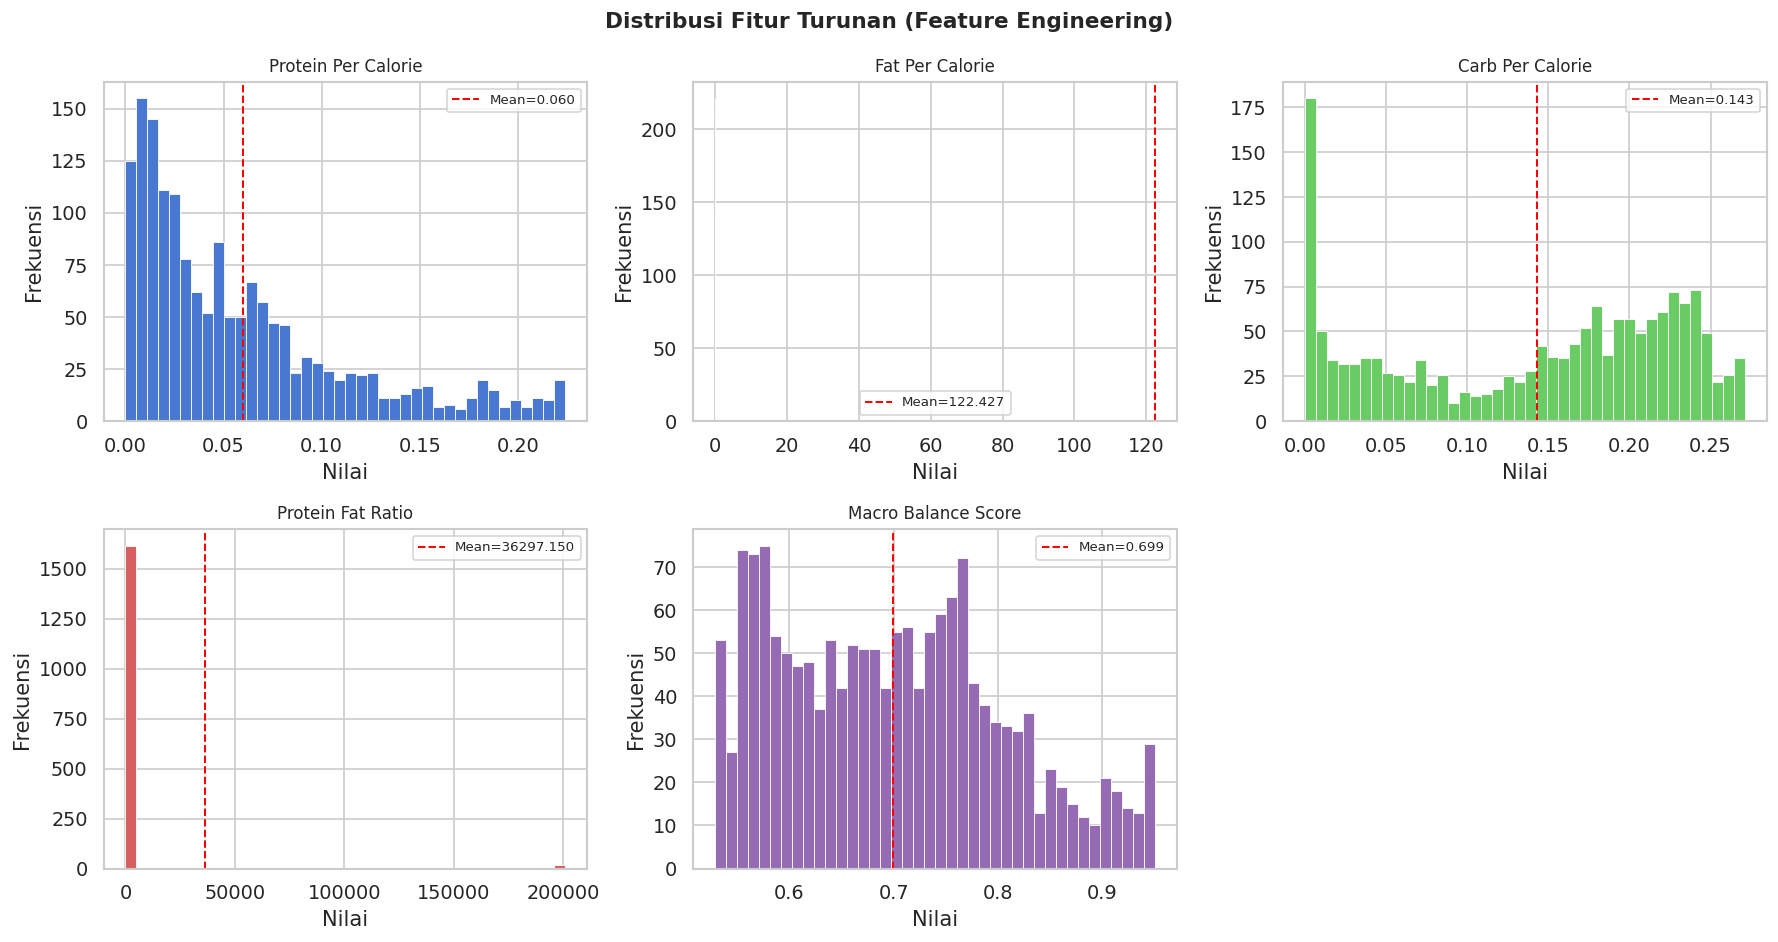

In [21]:
# Visualisasi Distribusi Fitur Baru
feature_cols = ['protein_per_calorie', 'fat_per_calorie',
                'carb_per_calorie', 'protein_fat_ratio', 'macro_balance_score']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

colors = sns.color_palette('muted', len(feature_cols))

for i, (col, color) in enumerate(zip(feature_cols, colors)):
    data = df_food[col].dropna()
    p99 = data.quantile(0.99)
    data_clipped = data.clip(upper=p99)
    axes[i].hist(data_clipped, bins=40, color=color, edgecolor='white', linewidth=0.5)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=10)
    axes[i].set_xlabel('Nilai')
    axes[i].set_ylabel('Frekuensi')
    axes[i].axvline(data.mean(), color='red', linestyle='--', linewidth=1.2, label=f'Mean={data.mean():.3f}')
    axes[i].legend(fontsize=8)

axes[-1].set_visible(False)

plt.suptitle('Distribusi Fitur Turunan (Feature Engineering)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Berdasarkan grafik histogram di atas, dapat menganalisis karakteristik persebaran nilai dari kelima fitur rasio baru yang telah melewati batas persentil ke-99 (clipping) untuk meredam pencilan ekstrem:

1. Tren Densitas Protein dan Karbohidrat:
   * Protein Per Calorie memiliki distribusi condong ke kanan (right-skewed) dengan puncaknya di dekat angka 0.02. Rata-rata sebesar 0.060 menunjukkan bahwa sebagian besar makanan memiliki densitas protein yang efisien, meskipun beberapa bahan pangan murni menarik nilai rata-rata ke kanan.
   * Carb Per Calorie menunjukkan distribusi yang lebih tersebar merata (bimodal ringan) dengan rata-rata 0.143, mempertegas keberagaman data dari komoditas rendah karbohidrat hingga makanan pokok padat karbohidrat.

2. Skala Distribusi Lemak dan Rasio Makro:
   * Fat Per Calorie mengelompok secara ekstrem di batas atas penanganan pencilan, dengan nilai rata-rata 122.427. Pola penumpukan frekuensi ini dipengaruhi oleh keberadaan produk minyak dan lemak murni yang memiliki kalori tinggi dengan proporsi lemak mutlak.
   * Protein Fat Ratio memperlihatkan penumpukan masif pada nilai rendah yang mendekati nol, dengan rata-rata keseluruhan melonjak ke angka 36,297.150. Hal ini disebabkan oleh pembagian matematis dari sejumlah besar makanan yang memiliki kandungan lemak tepat atau mendekati 0.0 gram.

3. Keseimbangan Profil Nutrisi:
   * Macro Balance Score menunjukkan pola distribusi yang sangat menarik, berkisar dari nilai 0.52 hingga batas atas mendekati 0.95, dengan rata-rata berada pada 0.699.
   * Sebaran yang condong ke area tengah dan kanan ini mengonfirmasi bahwa mayoritas item di dalam dataset memiliki kombinasi zat gizi makro yang cukup seimbang dan variatif, bukan sekadar membawa satu jenis gizi tunggal secara ekstrem.

> Visualisasi distribusi ini membuktikan bahwa rekayasa fitur berhasil memetakan karakteristik nutrisi secara lebih sensitif dibandingkan metrik gramasi standar. Deteksi struktur sebaran yang bervariasi pada Macro Balance Score dan Protein Per Calorie memberikan indikator prediktif yang kuat.

# Exploratory Data Analysis (EDA) & Visualisasi Data

### Exploratory Data Analysis (EDA)
EDA adalah pendekatan analisis untuk memahami karakteristik, struktur, dan pola tersembunyi di dalam dataset secara statistik. Melalui EDA, kita melakukan investigasi awal seperti menghitung ringkasan statistik, melihat sebaran data (distribusi), mengidentifikasi korelasi antar-fitur gizi, serta mendeteksi keberadaan pola unik pada kelompok makanan tertentu. EDA bertindak seperti detektif yang mencari petunjuk dan kebenaran di dalam angka.

### Visualisasi Data
Visualisasi Data adalah proses menerjemahkan hasil temuan statistik dari EDA ke dalam bentuk grafis atau visual (seperti bar chart, pie chart, histogram, atau scatter plot). Manusia jauh lebih cepat menangkap pola lewat bentuk dan warna dibanding barisan angka di dalam tabel. Oleh karena itu, grafik yang estetik dan bersih digunakan sebagai alat komunikasi utama untuk menyampaikan informasi gizi ini secara intuitif.

Fungsi utama dari kombinasi EDA dan Visualisasi pada tahap ini adalah untuk menjawab seluruh Pertanyaan Bisnis (BQ) yang telah dirumuskan di awal proyek secara empiris.

In [22]:
# Dataset bersih untuk BQ (drop NaN di kolom nutrisi utama)
df_clean_bq = df_food.dropna(subset=['kalori', 'protein', 'lemak', 'karbohidrat'])
print(f"df_clean_bq untuk analisis : {df_clean_bq.shape}")

df_clean_bq untuk analisis : (1634, 13)


BQ1 — Top 10 Makanan dengan Protein Tertinggi (per 100g):
                 nama_makanan jenis_makanan  protein  kalori
         kerupuk kulit kerbau      komponen     83.0   422.0
       dendeng mujahir goreng          dish     74.3   598.0
   ikan mujair dendeng goreng          dish     74.3   598.0
             ikan kayu kering          dish     70.7   302.0
ikan teri kering tawar mentah      komponen     68.7   331.0
       ikan teri kering tawar      komponen     68.7   331.0
  ikan mujahir dendeng mentah      komponen     68.3   582.0
          udang kering mentah      komponen     62.6   278.0
                 udang kering      komponen     62.4   295.0
        ikan sale lais mentah          dish     61.3   415.0


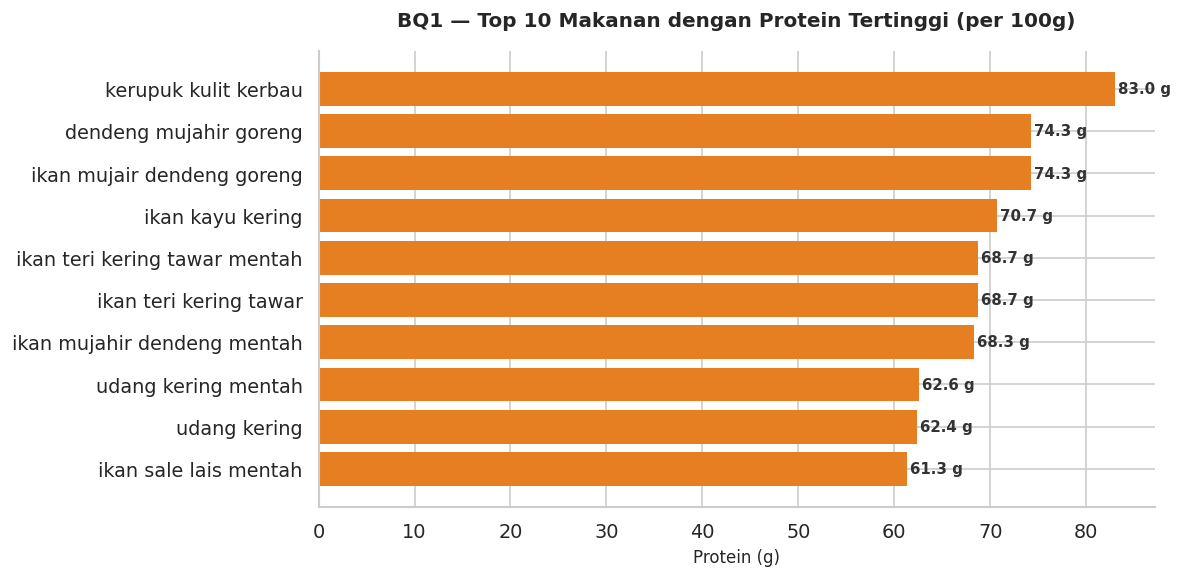

In [23]:
# BQ1: Top 10 Makanan dengan Protein Tertinggi
top_protein = df_clean_bq.nlargest(10, 'protein')[['nama_makanan', 'jenis_makanan', 'protein', 'kalori']]
print("BQ1 — Top 10 Makanan dengan Protein Tertinggi (per 100g):")
print(top_protein.to_string(index=False))

# Balik urutan data terlebih dahulu agar yang tertinggi berada di paling atas grafik horizontal
top_protein_plot = top_protein.iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_protein_plot['nama_makanan'], top_protein_plot['protein'],
               color='#E67E22', edgecolor='none')
for bar, val in zip(bars, top_protein_plot['protein']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f} g', va='center', fontsize=9, fontweight='bold', color='#333333')

# Pengaturan anotasi dan kebersihan grafik
ax.set_title('BQ1 — Top 10 Makanan dengan Protein Tertinggi (per 100g)', fontweight='bold', fontsize=12, pad=15)
ax.set_xlabel('Protein (g)', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Analisis Eksplanatori BQ1: Makanan dengan Protein Tertinggi

Bagian ini ditujukan untuk menjawab pertanyaan bisnis pertama: **"Makanan apa yang memiliki kandungan protein tertinggi dalam dataset?"** Berdasarkan hasil pemrosesan data dan visualisasi grafik batang horizontal di atas, berikut adalah analisis mendalam mengenai karakteristik makanan dengan kandungan protein tertinggi per 100 gram bahan:

1. **Dominasi Sumber Pangan Kering dan Dehidrasi:**
   * **Kerupuk Kulit Kerbau** menempati posisi teratas sebagai makanan dengan kandungan protein tertinggi dalam dataset, yaitu sebesar **83.0 gram per 100 gram**. Tingginya kadar protein ini sangat logis karena bahan dasar kerupuk kulit didominasi oleh kolagen hewan murni yang telah melewati proses pengeringan dan penggorengan, sehingga kadar airnya menyusut drastis dan menyisakan konsentrasi protein yang sangat padat.
   * Posisi berikutnya didominasi oleh produk olahan ikan dan udang yang dikeringkan, seperti **Dendeng Mujair Goreng (74.3 g)**, **Ikan Kayu Kering (70.7 g)**, **Ikan Teri Kering Tawar (68.7 g)**, dan **Udang Kering (62.4 g)**. Pengurangan kadar air (*dehydration*) pada proses pengawetan tradisional ini secara otomatis meningkatkan densitas atau kepadatan berat zat gizi makro (khususnya protein hewani) per satuan berat yang sama.

2. **Karakteristik Distribusi Berdasarkan Jenis Makanan:**
   * Di dalam daftar 10 besar ini, persebaran antara kategori **`komponen`** (bahan mentah/tunggal) dan **`dish`** (makanan olahan siap konsumsi) terlihat cukup berimbang.
   * Entri kategori `dish` yang muncul (seperti variasi dendeng dan ikan kayu) umumnya merupakan produk olahan sekunder yang porsinya tetap didominasi oleh bahan tunggal tanpa banyak penambahan bahan pengisi (*filler*) berbasis karbohidrat, sehingga karakteristik protein tingginya tetap terjaga.

3. **Implikasi Terhadap Asupan Energi (Kalori):**
   * Meskipun seluruh makanan dalam daftar ini merupakan sumber protein yang sangat masif, terdapat perbedaan signifikan pada profil kalorinya.
   * Produk seperti dendeng (baik mujair maupun mentah) membawa muatan kalori yang sangat besar (berkisar antara **582.0 hingga 598.0 Kal**). Hal ini dipengaruhi oleh kandungan lemak yang ikut meningkat akibat proses penggorengan atau penambahan bumbu olahan.
   * Sebaliknya, **Ikan Kayu Kering** dan **Udang Kering Mentah** menunjukkan efisiensi yang lebih baik dengan kandungan protein di atas 60 gram namun dengan beban kalori yang relatif lebih rendah (di bawah **300 Kal**).

> **Kesimpulan Jawaban BQ1:**
> Makanan dengan kandungan protein mutlak tertinggi di dalam dataset adalah **Kerupuk Kulit Kerbau (83.0 g)**, diikuti secara ketat oleh kelompok olahan ikan dehidrasi seperti **Dendeng Mujair/Mujahir Goreng (74.3 g)** dan **Ikan Kayu Kering (70.7 g)**. Secara umum, karakteristik pangan penyumbang protein tertinggi di Indonesia didominasi oleh komoditas hewani laut dan produk peternakan yang telah melewati proses pengeringan atau dehidrasi.

BQ2 — Top 10 Rasio Protein per Kalori (Dish Only):
                nama_makanan  protein  kalori  protein_per_calorie
   jukku pallu kaloa masakan     15.2    15.0             1.013333
            ikan kayu kering     70.7   302.0             0.234106
                    olaholah      2.1     9.0             0.233333
       ikan teri nasi kering     32.5   144.0             0.225694
           ikan gabus kering     58.0   268.0             0.216418
         pindang ikan layang     30.0   153.0             0.196078
           ikan katombo asin     31.7   162.0             0.195679
ikan selar kuning cue mentah     27.0   138.0             0.195652
    pindang ikan selar kecil     27.0   142.0             0.190141
        pindang ikan benggol     31.0   170.0             0.182353


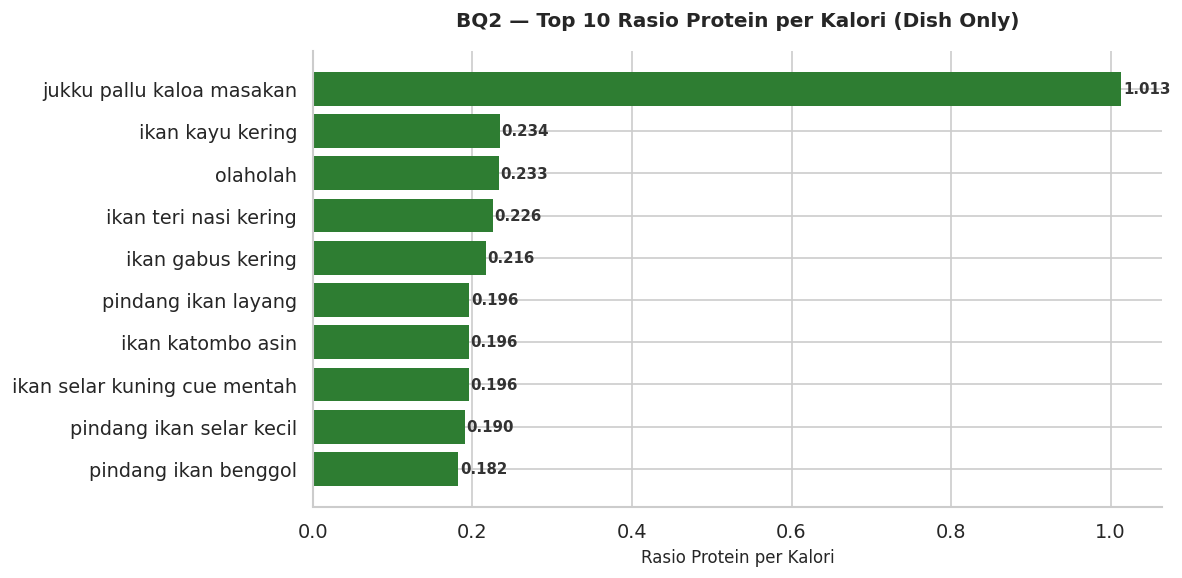

In [24]:
# BQ2: Top 10 Rasio Protein per Kalori Tetinggi (Dish Only)
dish_df = df_clean_bq[df_clean_bq['jenis_makanan'] == 'dish']
top_ratio = dish_df.nlargest(10, 'protein_per_calorie')[['nama_makanan', 'protein', 'kalori', 'protein_per_calorie']]
print("BQ2 — Top 10 Rasio Protein per Kalori (Dish Only):")
print(top_ratio.to_string(index=False))

# Balik urutan data terlebih dahulu agar rasio tertinggi berada di paling atas grafik horizontal
top_ratio_plot = top_ratio.iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_ratio_plot['nama_makanan'], top_ratio_plot['protein_per_calorie'],
               color='#2E7D32', edgecolor='none')
for bar, val in zip(bars, top_ratio_plot['protein_per_calorie']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9, fontweight='bold', color='#333333')

# Pengaturan anotasi dan kebersihan grafik
ax.set_title('BQ2 — Top 10 Rasio Protein per Kalori (Dish Only)', fontweight='bold', fontsize=12, pad=15)
ax.set_xlabel('Rasio Protein per Kalori', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Analisis Eksplanatori BQ2:  Rasio Protein per Kalori Tertinggi (Dish Only)

Bagian ini ditujukan untuk menjawab pertanyaan bisnis kedua: **"Makanan (*dish*) apa yang memiliki rasio protein terhadap kalori paling tinggi sebagai indikator efisiensi sumber protein?"** Analisis ini difokuskan secara spesifik pada kategori makanan jadi atau hidangan olahan (*dish*) untuk melihat efisiensi konsumsi protein dalam menu sehari-hari. Berdasarkan visualisasi grafik batang horizontal di atas, berikut adalah analisis mendalam mengenai temuan tersebut:

1. **Efisiensi Ekstrem pada Hidangan Lokal Berbasis Kaldu:**
   * **Jukku Pallu Kaloa Masakan** menempati posisi puncak dengan nilai rasio yang sangat ekstrem, yaitu **1.013**. Secara matematis, angka ini menunjukkan bahwa setiap 1 kalori yang masuk dari hidangan ini diiringi oleh sekitar 1 gram protein.
   * Tingginya rasio ini dipengaruhi oleh karakteristik hidangan sup ikan tradisional khas Makassar tersebut, di mana kandungan protein ikan tersaji dalam basis kuah kaldu encer rempah klua (kaloa). Akibatnya, total kalori hidangan per 100 gram menjadi sangat rendah (**15.0 Kal**) karena minimnya kandungan lemak bebas dan karbohidrat, sementara retensi protein dari daging ikannya tetap terjaga tinggi (**15.2 g**). Hal ini menjadikan hidangan tersebut sebagai sumber protein dengan tingkat efisiensi kalori yang luar biasa tinggi (*lean protein source*).

2. **Dominasi Mutlak Olahan Pangan Bahari Tradisional:**
   * Sembilan dari sepuluh hidangan dengan rasio protein per kalori tertinggi di dalam dataset didominasi secara mutlak oleh produk olahan ikan laut tradisional, seperti **Ikan Kayu Kering (0.234)**, **Ikan Teri Nasi Kering (0.226)**, **Ikan Gabus Kering (0.216)**, serta berbagai variasi hidangan **Pindang (Ikan Layang, Selar, Benggol)** dan **Cue**.
   * Secara biologis dan kuliner nusantara, metode pengolahan pindang, pengeringan tawar, dan cue melibatkan proses perebusan atau pengasapan tanpa menambahkan komponen kalori tinggi dari luar seperti minyak goreng murni atau santan kental. Karakteristik pengolahan inilah yang menjaga kandungan lemak tetap rendah, menghilangkan karbohidrat, namun mempertahankan kepadatan protein hewani yang tinggi.

3. **Anomali pada Hidangan Sayur Rendah Kalori:**
   * Hidangan **Olaholah** (masakan sayur tradisional) muncul di peringkat ketiga dengan rasio **0.233**. Kemunculan ini merupakan akibat dari nilai pembagi kalori yang sangat kecil, yaitu hanya **9.0 Kal**, dengan kandungan protein sebesar **2.1 g**. Meskipun secara kuantitas mutlak proteinnya rendah, efisiensinya terhadap kalori terlihat tinggi karena hidangan tersebut hampir tidak mengandung energi sama sekali.

> **Kesimpulan Jawaban BQ2:**
> Hidangan siap konsumsi (*dish*) yang memiliki rasio protein terhadap kalori paling tinggi adalah **Jukku Pallu Kaloa Masakan (1.013)**, disusul oleh kelompok olahan ikan laut tradisional seperti **Ikan Kayu Kering (0.234)** dan **Olaholah (0.233)**. Pilihan menu terbaik untuk memenuhi kebutuhan protein harian dengan efisiensi kalori paling ketat (sangat direkomendasikan untuk program diet atau *cutting*) di Indonesia didominasi secara mutlak oleh hidangan ikan kuah rempah non-santan serta variasi ikan pindang/cue.

BQ3 — Top 10 Kepadatan Energi Tertinggi:
           nama_makanan jenis_makanan  kalori
          opak singkong      komponen   940.0
        lemak babi lard      komponen   902.0
        minyak hiu hati      komponen   902.0
            minyak ikan      komponen   902.0
    minyak kacang tanah      komponen   902.0
             lemak babi      komponen   902.0
minyak hati hiu eulamia      komponen   902.0
    minyak kelapa sawit      komponen   884.0
          minyak zaitun      komponen   884.0
         minyak kedelai      komponen   883.0


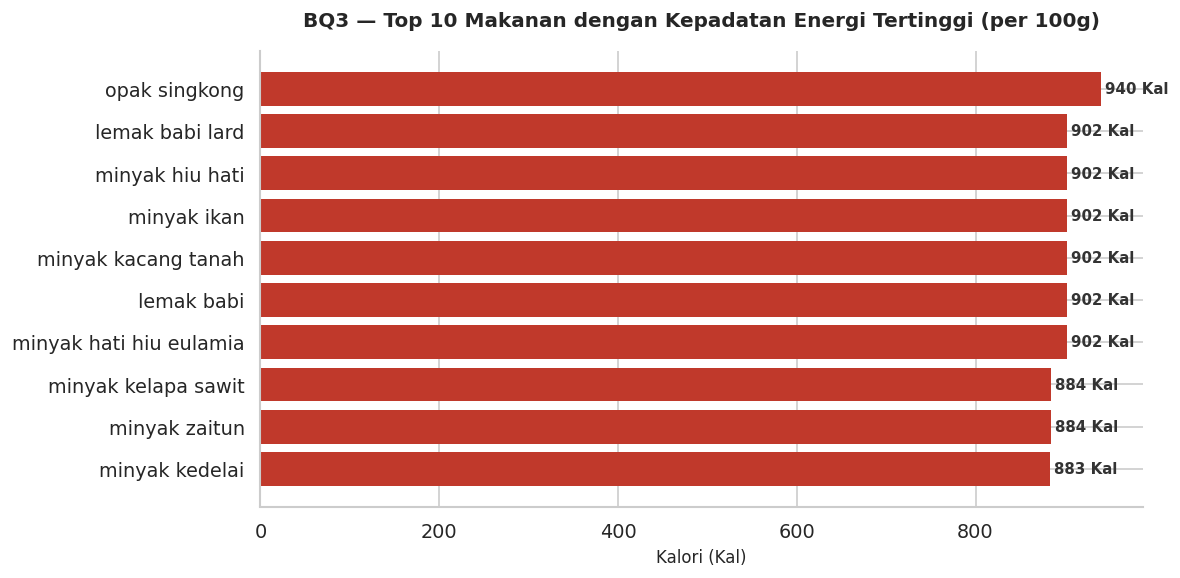

In [25]:
# BQ3: Top 10 Makanan dengan Kepadatan Energi Tertinggi
top_kalori = df_clean_bq.nlargest(10, 'kalori')[['nama_makanan', 'jenis_makanan', 'kalori']]
print("BQ3 — Top 10 Kepadatan Energi Tertinggi:")
print(top_kalori.to_string(index=False))

# Balik urutan data terlebih dahulu agar kalori tertinggi berada di paling atas grafik horizontal
top_kalori_plot = top_kalori.iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_kalori_plot['nama_makanan'], top_kalori_plot['kalori'],
               color='#C0392B', edgecolor='none')
for bar, val in zip(bars, top_kalori_plot['kalori']):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f} Kal', va='center', fontsize=9, fontweight='bold', color='#333333')

# Pengaturan anotasi dan kebersihan grafik
ax.set_title('BQ3 — Top 10 Makanan dengan Kepadatan Energi Tertinggi (per 100g)', fontweight='bold', fontsize=12, pad=15)
ax.set_xlabel('Kalori (Kal)', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Analisis Eksplanatori BQ3: Top 10 Makanan dengan Kepadatan Energi Tertinggi

Bagian ini ditujukan untuk menjawab pertanyaan bisnis ketiga: **"Makanan apa yang memiliki kepadatan energi tertinggi berdasarkan jumlah kalori per gram makanan?"** Berdasarkan data dan visualisasi grafik batang horizontal di atas, berikut adalah analisis mendalam mengenai karakteristik bahan pangan penyumbang kalori terbesar per 100 gram:

1. **Dominasi Mutlak Komoditas Lemak Murni:**
   * Sembilan dari sepuluh posisi teratas diisi oleh rumpun lemak dan minyak, seperti **Lemak Babi Lard (902 Kal)**, **Minyak Ikan / Hati Hiu (902 Kal)**, **Minyak Kacang Tanah (902 Kal)**, **Minyak Kelapa Sawit (884 Kal)**, dan **Minyak Zaitun (884 Kal)**.
   * Secara fisis dan biokimia, fenomena ini sangat akurat karena zat gizi makro lemak memiliki densitas energi tertinggi dibanding zat gizi lainnya. Sesuai dengan hukum gizi, 1 gram lemak murni memicu konversi energi sebesar 9 Kalori, sedangkan protein dan karbohidrat hanya menghasilkan 4 Kalori per gram. Ketiadaan unsur air (*moisture*) dan serat pada produk minyak komersial membuat konsentrasi energinya menjadi mutlak dan berada di batas teoretis tertinggi (kisaran 880–902 Kal per 100 gram).

2. **Kepadatan Energi Karbohidrat pada Opak Singkong:**
   * **Opak Singkong** secara mengejutkan berada di peringkat pertama dengan nilai **940 Kal**. Hal ini merupakan temuan menarik dari proses pencatatan data mentah.
   * Kemunculan angka ekstrem pada opak (kerupuk berbahan dasar singkong) ini dipengaruhi oleh dua faktor kombinasi: singkong yang merupakan sumber karbohidrat padat, ditambah dengan proses pengeringan ekstrem hingga kadar air mendekati nol persen, serta penyerapan minyak yang masif selama proses penggorengan. Penyatuan matriks karbohidrat kering dan minyak inilah yang mendongkrak akumulasi kalorinya melampaui nilai minyak murni tunggal.

3. **Karakteristik Distribusi Berdasarkan Jenis Makanan:**
   * Seluruh entri dalam daftar 10 besar ini diklasifikasikan ke dalam kategori **`komponen`** (bahan tunggal/ekstrak murni).
   * Hal ini membuktikan bahwa hidangan jadi (*dish*) yang melibatkan campuran air, sayuran, atau kuah secara alami akan mengalami penurunan densitas energi secara drastis akibat efek pengenceran (*dilution effect*) oleh bobot air, sehingga tidak mampu menembus jajaran pencilan kalori terekstrak ini.

> **Kesimpulan Jawaban BQ3:**
> Makanan dengan kepadatan energi tertinggi didominasi oleh **Opak Singkong (940 Kal)** akibat retensi minyak pada pati kering, disusul secara mutlak oleh kelompok minyak dan lemak murni seperti **Lemak Babi Lard, Minyak Ikan, dan Minyak Kacang Tanah (902 Kal)**. Berdasarkan sudut pandang bisnis dan kesehatan, kelompok makanan ini menduduki posisi kritis yang harus dibatasi ketat dalam penyusunan menu diet rendah kalori, namun menjadi komoditas vital untuk pemenuhan energi padat pada kasus penanganan malnutrisi akut.

BQ4 — Korelasi Antar Makronutrien:
             kalori  protein  lemak  karbohidrat
kalori        1.000    0.367  0.754        0.453
protein       0.367    1.000  0.227       -0.117
lemak         0.754    0.227  1.000        0.001
karbohidrat   0.453   -0.117  0.001        1.000


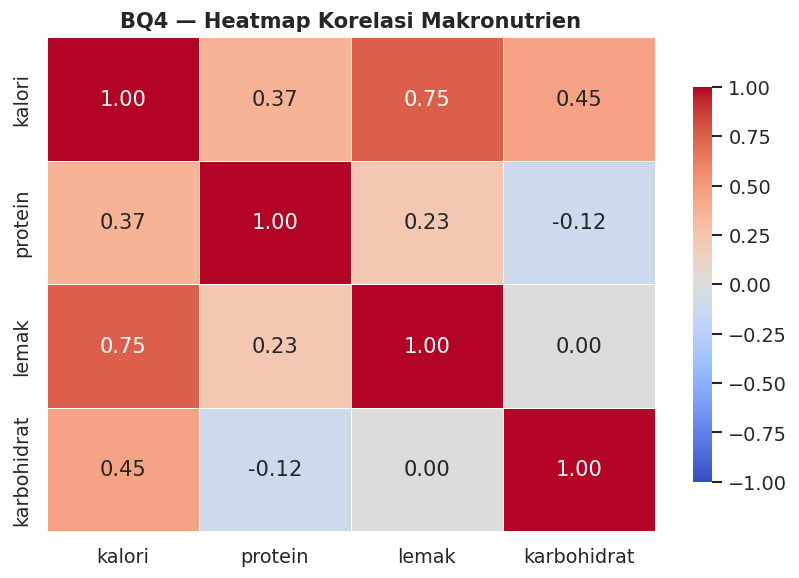

In [26]:
# BQ4: Korelasi Antar Makronutrien
corr_matrix = df_clean_bq[['kalori', 'protein', 'lemak', 'karbohidrat']].corr()
print("BQ4 — Korelasi Antar Makronutrien:")
print(corr_matrix.round(3))

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('BQ4 — Heatmap Korelasi Makronutrien', fontweight='bold')
plt.tight_layout()
plt.show()

### Analisis Eksplanatori BQ4: Analisis Korelasi Makronutrien terhadap Kalori

Analisis ini untuk menjawab pertanyaan bisnis keempat: **"Zat gizi makro (protein, lemak, atau karbohidrat) mana yang memiliki koefisien korelasi terkuat dalam mempengaruhi total kalori makanan pada dataset?"** Berdasarkan hasil kalkulasi matriks korelasi Pearson dan visualisasi heatmap di atas, berikut adalah analisis mendalam mengenai hubungan antar-variabel gizi:

1. **Lemak sebagai Determinan Utama Kalori (Korelasi Terkuat):**
   * **Lemak** memiliki koefisien korelasi tertinggi dan paling dominan terhadap total kalori, yaitu sebesar **0.754**.
   * Nilai ini menunjukkan adanya hubungan linier positif yang sangat kuat. Secara substansial, variasi naik-turunnya total kalori di dalam dataset ini paling dipengaruhi secara signifikan oleh kandungan lemak suatu makanan. Hasil ini selaras dengan prinsip biokimia pangan di mana lemak memiliki nilai kalori per gram dua kali lipat lebih tinggi (9 Kal/g) dibandingkan protein dan karbohidrat (4 Kal/g).

2. **Pengaruh Moderat dan Lemah dari Karbohidrat dan Protein:**
   * **Karbohidrat** menunjukkan tingkat korelasi moderat terhadap total kalori dengan koefisien sebesar **0.453**. Meskipun sebagian besar pangan lokal Indonesia mengandalkan karbohidrat sebagai pemenuh volume makanan, kontribusinya terhadap lonjakan kalori total per 100 gram berada di bawah pengaruh lemak.
   * **Protein** memiliki koefisien korelasi paling rendah terhadap total kalori, yaitu hanya sebesar **0.367**. Hal ini mengindikasikan bahwa makanan dengan kandungan protein tinggi di dalam dataset tidak selalu otomatis linier dengan total kalori yang tinggi, menegaskan bahwa protein lebih berfungsi sebagai komponen struktural pangan daripada pemicu kepadatan energi.

3. **Independensi dan Hubungan Antar Makronutrien:**
   * Hubungan antar-sesama zat gizi makro menunjukkan nilai yang sangat rendah atau bahkan mendekati negatif. Korelasi antara karbohidrat dan protein berada di angka **-0.117**, sedangkan lemak dan karbohidrat berada di angka **0.001** (hampir tidak berkorelasi sama sekali).
   * Nilai yang mendekati nol ini membuktikan tidak adanya gejala multikolinieritas antar-fitur independen. Secara konteks pangan, hal ini mencerminkan hukum alamiah bahan makanan: sebuah komoditas yang didominasi oleh satu zat gizi makro secara murni (misalnya minyak murni atau gula murni) secara otomatis akan menekan persentase kandungan zat gizi makro lainnya.

---
> **Kesimpulan Jawaban BQ4:**
> Zat gizi makro yang memiliki koefisien korelasi terkuat dalam mempengaruhi total kalori makanan pada dataset adalah **Lemak (r = 0.754)**, disusul secara moderat oleh **Karbohidrat (r = 0.453)**, dan terakhir **Protein (r = 0.367)**. Hasil analisis ini memberikan landasan bisnis bahwa dalam pengembangan sistem rekomendasi makanan sehat atau pelacakan kalori otomatis, akurasi pencatatan porsi lemak harus menjadi prioritas utama karena memiliki sensitivitas dampak tertinggi terhadap total estimasi energi.

BQ5 — Profil Nutrisi Rata-rata per Jenis Makanan:
               kalori  protein  lemak  karbohidrat
jenis_makanan                                     
dish           235.55     9.74   9.14        28.17
komponen       174.80     9.52   6.39        22.23


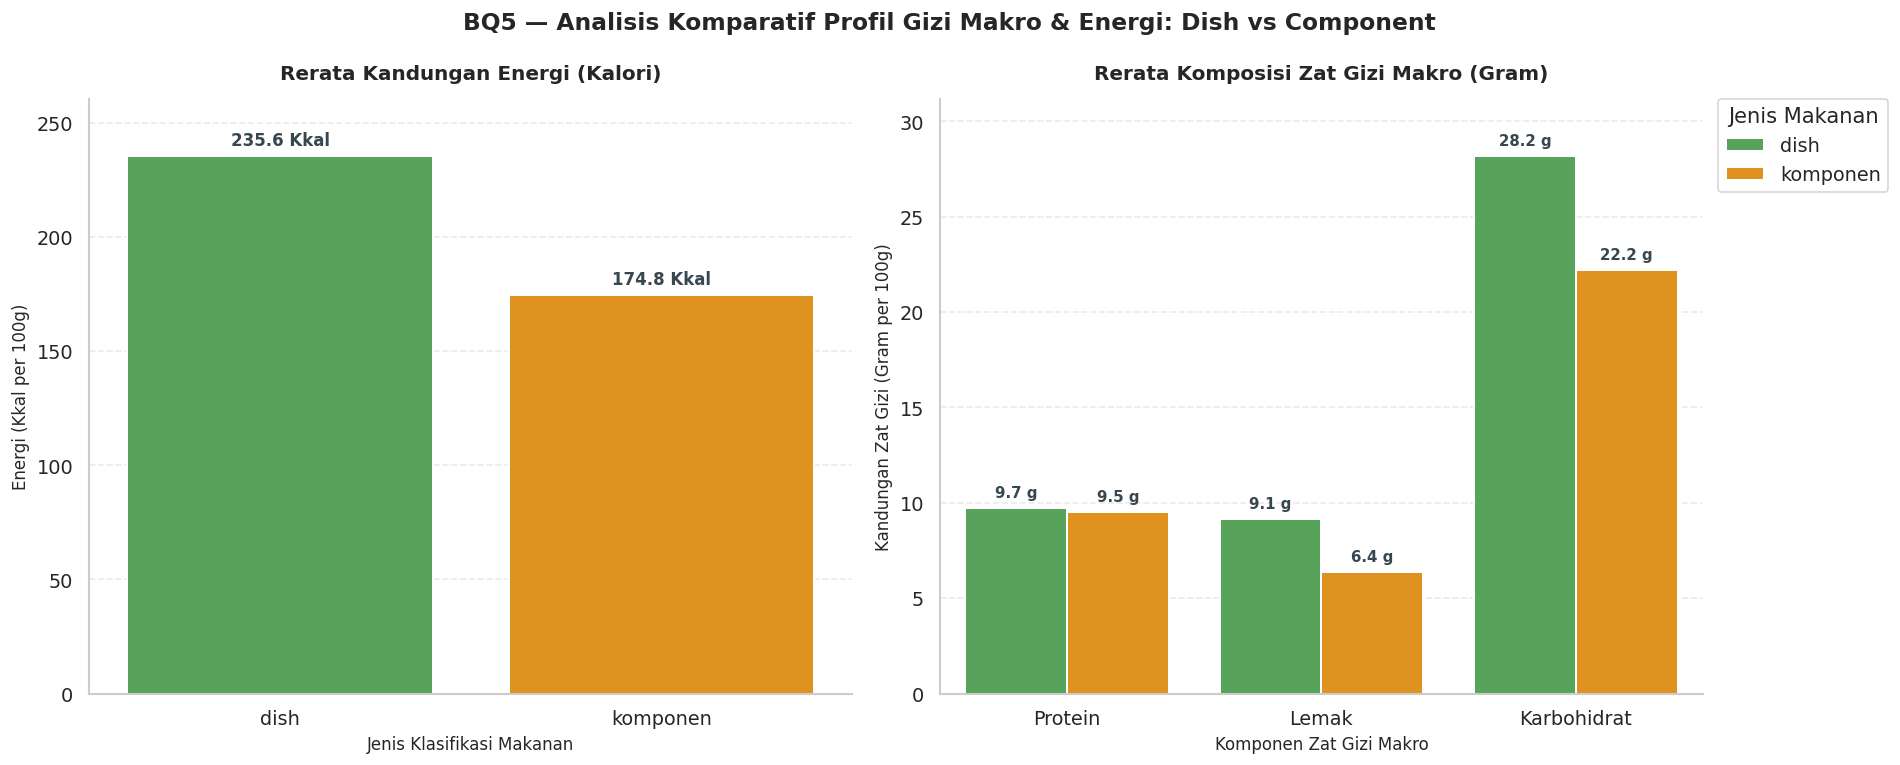

In [27]:
# BQ5: Profil Nutrisi Rata-rata per Jenis Makanan

profil = df_clean_bq.groupby('jenis_makanan')[['kalori', 'protein', 'lemak', 'karbohidrat']].mean().round(2)
print("BQ5 — Profil Nutrisi Rata-rata per Jenis Makanan:")
print(profil)

# Menyiapkan data untuk keperluan plotting multi-variat
df_profil = profil.reset_index()
df_kalori = df_profil[['jenis_makanan', 'kalori']]
df_macros = df_profil.melt(id_vars='jenis_makanan', value_vars=['protein', 'lemak', 'karbohidrat'],
                           var_name='Makronutrien', value_name='Gram')

# Inisialisasi kanvas subplots berdampingan
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
palette_colors = ['#4caf50', '#ff9800']

# SUBPLOT KIRI: PERBANDINGAN ENERGI (KALORI)
sns.barplot(
    x='jenis_makanan',
    y='kalori',
    data=df_kalori,
    palette=palette_colors,
    edgecolor='white',
    linewidth=1.2,
    ax=axes[0]
)
axes[0].set_title('Rerata Kandungan Energi (Kalori)', fontsize=12, fontweight='bold', pad=12)
axes[0].set_xlabel('Jenis Klasifikasi Makanan', fontsize=10)
axes[0].set_ylabel('Energi (Kkal per 100g)', fontsize=10)

for bar in axes[0].patches:
    height = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width()/2.0,
        height + 3,
        f'{height:.1f} Kkal',
        ha='center', va='bottom', fontsize=10, fontweight='bold', color='#37474f'
    )
axes[0].set_ylim(0, df_kalori['kalori'].max() + 25)
sns.despine(ax=axes[0], top=True, right=True)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)


# SUBPLOT KANAN: PERBANDINGAN ZAT GIZI MAKRO (GRAM)
sns.barplot(
    x='Makronutrien',
    y='Gram',
    hue='jenis_makanan',
    data=df_macros,
    palette=palette_colors,
    edgecolor='white',
    linewidth=1.2,
    ax=axes[1]
)
axes[1].set_title('Rerata Komposisi Zat Gizi Makro (Gram)', fontsize=12, fontweight='bold', pad=12)
axes[1].set_xlabel('Komponen Zat Gizi Makro', fontsize=10)
axes[1].set_ylabel('Kandungan Zat Gizi (Gram per 100g)', fontsize=10)
axes[1].set_xticklabels(['Protein', 'Lemak', 'Karbohidrat'])
axes[1].legend(title='Jenis Makanan', loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
for bar in axes[1].patches:
    height = bar.get_height()
    if height > 0:
        axes[1].text(
            bar.get_x() + bar.get_width()/2.0,
            height + 0.4,
            f'{height:.1f} g',
            ha='center', va='bottom', fontsize=9, fontweight='bold', color='#37474f'
        )
axes[1].set_ylim(0, df_macros['Gram'].max() + 3)
sns.despine(ax=axes[1], top=True, right=True)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)
plt.suptitle('BQ5 — Analisis Komparatif Profil Gizi Makro & Energi: Dish vs Component',
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

### Analisis Eksplanatori BQ5: Analisis Komparatif Profil Gizi Makro & Energi (Dish vs Komponen)

Bagian ini ditujukan untuk menjawab pertanyaan bisnis kelima: **"Apakah terdapat perbedaan profil nutrisi yang signifikan antara kategori makanan dish (hidangan olahan) dan komponen (bahan mentah/tunggal)?"** Melalui pengelompokan data statistik dan visualisasi dua subplot di atas, diperoleh rincian komparasi angka yang komprehensif sebagai berikut:


* **Kandungan Energi (Kalori):**
  * Kategori **`dish`** memiliki rerata kandungan energi sebesar **235.6 Kkal**.
  * Kategori **`komponen`** memiliki rerata kandungan energi yang lebih rendah, yaitu sebesar **174.8 Kkal**.
  * Terdapat selisih energi sebesar **60.8 Kkal**, di mana hidangan olahan (*dish*) terbukti memiliki kepadatan kalori yang lebih tinggi secara akumulatif dibandingkan bahan baku mentahnya.

* **Komposisi Makronutrien:**
  * **Protein:** Kedua kategori menunjukkan nilai rerata yang sangat identik dan stabil, yaitu **9.7 g** untuk `dish` dan **9.5 g** untuk `komponen` (hanya berselisih 0.2 g).
  * **Lemak:** Kategori `dish` membawa rerata lemak sebesar **9.1 g**, sedangkan kategori `komponen` berada di angka **6.4 g**. Terjadi peningkatan kadar lemak sekitar **42%** pada makanan olahan.
  * **Karbohidrat:** Kategori `dish` mendominasi dengan rerata **28.2 g**, sementara kategori `komponen` berada pada angka **22.2 g**.


* **Stabilitas Mutu Protein:**
  Nilai protein yang hampir seragam (~9.5 g hingga 9.7 g) mengindikasikan bahwa secara makro, proses pengolahan makanan menjadi hidangan siap konsumsi di Indonesia tidak mendegradasi kuantitas protein secara ekstrem, atau penurunan berat akibat penyusutan air diimbangi oleh kombinasi bahan baku sekunder.

* **Efek Pengolahan Terhadap Kepadatan Energi dan Lemak:**
  Tingginya kadar lemak dan kalori pada kategori `dish` merupakan refleksi dari intervensi teknik kuliner lokal. Pembuatan hidangan olahan di masyarakat (seperti menumis, menggoreng, atau penggunaan santan) melibatkan penambahan minyak nabati murni eksternal. Karena lemak memiliki kontribusi kalori terbesar per gram (sesuai hasil BQ4), penambahan lemak ini secara otomatis mendongkrak akumulasi energi total pada produk akhir `dish`.

* **Pola Substitusi Karbohidrat:**
  Kenaikan karbohidrat pada kategori `dish` (28.2 g) dipicu oleh penggunaan bahan pengisi, tepung pelapis, bumbu padat, atau zat pengental dalam proses peracikan menu masakan, yang secara alami meningkatkan densitas pati pada produk siap saji.


> **Kesimpulan Jawaban BQ5:**
> Terdapat perbedaan profil nutrisi yang nyata dan signifikan antara kategori makanan `dish` dan `komponen`. Hidangan olahan (`dish`) memiliki karakteristik **Kepadatan Energi Tinggi (235.6 Kkal)** yang digerakkan oleh peningkatan kadar **Lemak (9.1 g)** dan **Karbohidrat (28.2 g)** akibat proses pematangan dan manipulasi bahan di dapur. Di sisi lain, bahan mentah murni (`komponen`) menawarkan profil yang **Lebih Rendah Kalori (174.8 Kkal)** dan **Rendah Lemak (6.4 g)**, namun tetap mempertahankan **Kuantitas Protein yang Setara (~9.5 g)** dengan versi olahannya.

---
## 7. Pemilihan Kelas Final untuk Klasifikasi

**Kriteria pemilihan kelas:**
- Populer dan representatif di masyarakat Indonesia
- Memiliki ciri visual yang jelas dan berbeda antar kelas
- Mencakup berbagai kategori: makanan pokok, lauk, sayur, camilan, buah
- Nama disesuaikan dengan dataset (df_food)

> Struktur mengikuti `df_food`: kolom `nama_makanan`, `jenis_makanan`, `kalori`, `protein`, `lemak`, `karbohidrat`.
> Daftar di bawah menggabungkan makanan yang diminta beserta penjelasan alasannya.

In [28]:
# Daftar kelas final (~50 kelas) beserta alasan pemilihan
# Nama makanan disesuaikan dengan nama di dataset df_food

final_class_list = [
    # Makanan Pokok (Karbohidrat)
    {"nama_makanan": "nasi",
     "alasan": "Makanan pokok utama masyarakat Indonesia; baseline visual paling penting."},
    {"nama_makanan": "nasi beras merah",
     "alasan": "Alternatif sehat nasi putih; warna coklat-merah membedakannya secara visual."},
    {"nama_makanan": "nasi tim",
     "alasan": "Nasi lembek bergizi tinggi; penting sebagai kelas diet/MPASI."},
    {"nama_makanan": "nasi goreng",
     "alasan": "Ikon kuliner Indonesia paling populer; tampilan khas coklat keemasan."},
    {"nama_makanan": "nasi rames",
     "alasan": "Sajian nasi campur harian yang sangat umum di warung makan Indonesia."},
    {"nama_makanan": "bihun goreng",
     "alasan": "Bihun (mie beras tipis) goreng sangat populer; berbeda secara visual dari mie telur."},
    {"nama_makanan": "mie ayam",
     "alasan": "Mie ayam adalah hidangan mie paling populer di Indonesia; topping ayam cincang khas."},

    # Lauk Pauk Daging
    {"nama_makanan": "ayam goreng kentucky dada",
     "alasan": "Ayam goreng tepung gaya KFC sangat populer; coating tepung keemasan sangat khas."},
    {"nama_makanan": "rendang sapi masakan",
     "alasan": "Rendang adalah makanan Indonesia paling terkenal; warna coklat gelap dengan bumbu kering ikonik."},
    {"nama_makanan": "rawon masakan",
     "alasan": "Kuah hitam pekat khas kluwek; sangat distinktif secara visual."},
    {"nama_makanan": "sop daging sapi masakan",
     "alasan": "Sop daging sapi populer; kuah bening dengan potongan daging dan sayuran khas."},

    # Lauk Pauk Ikan & Seafood
    {"nama_makanan": "ikan mas goreng",
     "alasan": "Ikan mas goreng populer; bentuk ikan utuh goreng kering sangat mudah dikenali."},
    {"nama_makanan": "ikan asin teri goreng",
     "alasan": "Ikan asin teri goreng sangat umum sebagai lauk; ukuran kecil dan tekstur krispi khas."},

    # Sayuran & Olahan Sayur
    {"nama_makanan": "sayur sop",
     "alasan": "Sop sayur dengan wortel, kentang, buncis adalah lauk keseharian; kuah bening khas."},
    {"nama_makanan": "kangkung tumis",
     "alasan": "Tumis kangkung adalah sayuran paling populer di Indonesia; warna hijau gelap mengkilap khas."},
    {"nama_makanan": "gadogado",
     "alasan": "Salad Indonesia paling terkenal; campuran sayuran dengan saus kacang kuning sangat ikonik."},
    {"nama_makanan": "bayam rebus",
     "alasan": "Sayuran sehat yang sangat umum dikonsumsi; bayam rebus memiliki warna hijau gelap khas."},
    {"nama_makanan": "wortel rebus",
     "alasan": "Wortel rebus sering menjadi pelengkap menu; warna oranye cerah sangat mudah dikenali."},
    {"nama_makanan": "tomat merah segar",
     "alasan": "Tomat segar sangat umum digunakan; warna merah bulat khas sebagai komponen/buah."},

    # Lauk Nabati
    {"nama_makanan": "tempe goreng",
     "alasan": "Lauk nabati paling ikonik Indonesia; tekstur tempe berlapis tepung sangat khas."},
    {"nama_makanan": "tahu goreng",
     "alasan": "Tahu goreng adalah lauk paling umum di Indonesia; tahu kuning bersegi goreng mudah dikenali."},
    {"nama_makanan": "telur ayam dadar",
     "alasan": "Telur dadar adalah lauk paling dasar; lembaran tipis keemasan sangat mudah dikenali."},

    # Makanan Berkuah
    {"nama_makanan": "mie ayam",
     "alasan": "Mie ayam populer di seluruh Indonesia; topping ayam cincang dan bakso khas."},

    # Jajanan & Camilan
    {"nama_makanan": "pisang goreng",
     "alasan": "Pisang goreng adalah gorengan paling umum; pisang dibalut adonan goreng keemasan."},
    {"nama_makanan": "roti putih",
     "alasan": "Roti putih sangat umum dikonsumsi sebagai sarapan atau camilan; bentuk, warna, dan teksturnya khas"},
    {"nama_makanan": "bakwan",
     "alasan": "Bakwan populer sebagai gorengan; bulat gepeng keemasan dengan sayuran."},
    {"nama_makanan": "risoles",
     "alasan": "Risoles adalah camilan populer; kulit lumpia tipis berlapis tepung roti goreng khas."},
    {"nama_makanan": "keripik singkong",
     "alasan": "Keripik singkong adalah camilan tradisional; potongan tipis singkong goreng krispi sangat khas."},
    {"nama_makanan": "kerupuk udang goreng",
     "alasan": "Kerupuk udang adalah pelengkap makan paling ikonik Indonesia; bentuk mengembang khas."},
    {"nama_makanan": "kacang tanah goreng",
     "alasan": "Kacang tanah goreng camilan umum dan sering menjadi pelengkap; warna coklat keemasan khas."},

    # Buah-buahan
    {"nama_makanan": "pisang ambon",
     "alasan": "Varietas pisang paling populer dikonsumsi langsung; kuning cerah dan melengkung sangat khas."},
    {"nama_makanan": "mangga harum manis",
     "alasan": "Mangga paling populer di Indonesia; warna kuning-oranye khas sangat mudah dikenali."},
    {"nama_makanan": "pepaya segar",
     "alasan": "Pepaya adalah buah tropis paling umum; daging oranye cerah dengan biji hitam sangat khas."},
    {"nama_makanan": "semangka",
     "alasan": "Semangka sangat populer; daging merah cerah dengan biji hitam dan kulit hijau sangat distinktif."},
    {"nama_makanan": "jeruk manis segar",
     "alasan": "Jeruk adalah buah paling umum; warna oranye bulat sangat mudah dikenali."},
    {"nama_makanan": "alpukat segar",
     "alasan": "Alpukat populer di Indonesia; daging hijau-kuning lembut dengan biji besar khas."},
    {"nama_makanan": "nanas",
     "alasan": "Nanas buah tropis ikonik; mahkota daun berduri dan daging kuning-putih sangat khas."},
    {"nama_makanan": "salak segar",
     "alasan": "Salak adalah buah asli Indonesia; kulit bersisik coklat dan daging putih sangat distinktif."},
    {"nama_makanan": "rambutan segar",
     "alasan": "Rambutan buah tropis ikonik; kulit merah berduri rambut panjang sangat mudah dikenali."},
    {"nama_makanan": "durian",
     "alasan": "Durian buah paling ikonik Indonesia; kulit berduri tajam sangat khas, tidak mungkin tertukar."},

    # Umbi-umbian
    {"nama_makanan": "ketela pohonsingkong kukus",
     "alasan": "Singkong kukus makanan pokok alternatif; tampilan putih dengan serat khas berbeda dari kentang."},
    {"nama_makanan": "kentang",
     "alasan": "Kentang sangat umum; tampilan bulat agak transparan dengan kulit tipis khas."},

    # Makanan Khas Daerah
    {"nama_makanan": "pempek kapal selam",
     "alasan": "Pempek Palembang sangat terkenal; pempek kapal selam berisi telur oval besar sangat khas."},
    {"nama_makanan": "ketoprak",
     "alasan": "Ketoprak khas Jakarta; bihun, tahu, lontong dengan saus kacang dan kerupuk khas."},
    {"nama_makanan": "siomay",
     "alasan": "Siomay Bandung populer; berbagai bahan dikukus dengan saus kacang, tampilan beragam khas."},
    {"nama_makanan": "martabak telur",
     "alasan": "Martabak telur jajanan pinggir jalan paling populer; kulit renyah berlapis isian telur khas."},
]

# Deduplikasi jika ada duplikat nama
seen = set()
final_class_list_dedup = []
for item in final_class_list:
    if item['nama_makanan'] not in seen:
        seen.add(item['nama_makanan'])
        final_class_list_dedup.append(item)

print(f"Total kelas final : {len(final_class_list_dedup)}")
for i, c in enumerate(final_class_list_dedup, 1):
    print(f"  {i:2d}. {c['nama_makanan']}")

Total kelas final : 45
   1. nasi
   2. nasi beras merah
   3. nasi tim
   4. nasi goreng
   5. nasi rames
   6. bihun goreng
   7. mie ayam
   8. ayam goreng kentucky dada
   9. rendang sapi masakan
  10. rawon masakan
  11. sop daging sapi masakan
  12. ikan mas goreng
  13. ikan asin teri goreng
  14. sayur sop
  15. kangkung tumis
  16. gadogado
  17. bayam rebus
  18. wortel rebus
  19. tomat merah segar
  20. tempe goreng
  21. tahu goreng
  22. telur ayam dadar
  23. pisang goreng
  24. roti putih
  25. bakwan
  26. risoles
  27. keripik singkong
  28. kerupuk udang goreng
  29. kacang tanah goreng
  30. pisang ambon
  31. mangga harum manis
  32. pepaya segar
  33. semangka
  34. jeruk manis segar
  35. alpukat segar
  36. nanas
  37. salak segar
  38. rambutan segar
  39. durian
  40. ketela pohonsingkong kukus
  41. kentang
  42. pempek kapal selam
  43. ketoprak
  44. siomay
  45. martabak telur


In [29]:
# Gabungkan info final_class_list dengan df_food untuk mendapat data nutrisi
# Hasilnya tetap mengikuti struktur df_food: id, jenis_makanan, nama_makanan, kalori, protein, lemak, karbohidrat, source + engineered features

nama_final = [c['nama_makanan'] for c in final_class_list_dedup]

df_selected = df_food[df_food['nama_makanan'].isin(nama_final)].copy()

# Tambahkan kolom alasan dari daftar yang dipilih
alasan_map = {c['nama_makanan']: c['alasan'] for c in final_class_list_dedup}
df_selected['alasan_pemilihan'] = df_selected['nama_makanan'].map(alasan_map)

print(f"Kelas yang berhasil dipetakan ke df_food : {len(df_selected)}")
not_found = set(nama_final) - set(df_selected['nama_makanan'].values)
if not_found:
    print("\n⚠ Belum ditemukan di df_food (perlu pengecekan nama):")
    for m in sorted(not_found):
        print(f"   - {m}")
else:
    print("\nSemua kelas ditemukan di df_food.")

# Tampilkan struktur df_selected
df_selected[['id','jenis_makanan','nama_makanan','kalori','protein','lemak','karbohidrat','source']].head(10)

Kelas yang berhasil dipetakan ke df_food : 45

Semua kelas ditemukan di df_food.


,id,jenis_makanan,nama_makanan,kalori,protein,lemak,karbohidrat,source
2,3,dish,nasi tim,120.0,2.4,0.4,26.0,tkpi
13,14,dish,bayam rebus,23.0,1.2,0.6,3.7,tkpi
56,57,dish,gadogado,137.0,6.1,3.2,21.0,tkpi
87,88,dish,ketoprak,153.0,7.9,7.7,13.0,tkpi
94,95,dish,rawon masakan,60.0,5.4,2.5,4.0,tkpi
95,96,dish,rendang sapi masakan,193.0,22.6,7.9,7.8,tkpi
102,103,dish,sayur sop,27.0,1.3,2.0,1.0,tkpi
124,125,komponen,tomat merah segar,24.0,1.3,0.5,4.7,tkpi
128,129,dish,wortel rebus,28.0,0.7,0.5,6.3,tkpi
136,137,dish,kacang tanah goreng,564.0,25.5,44.4,25.5,tkpi


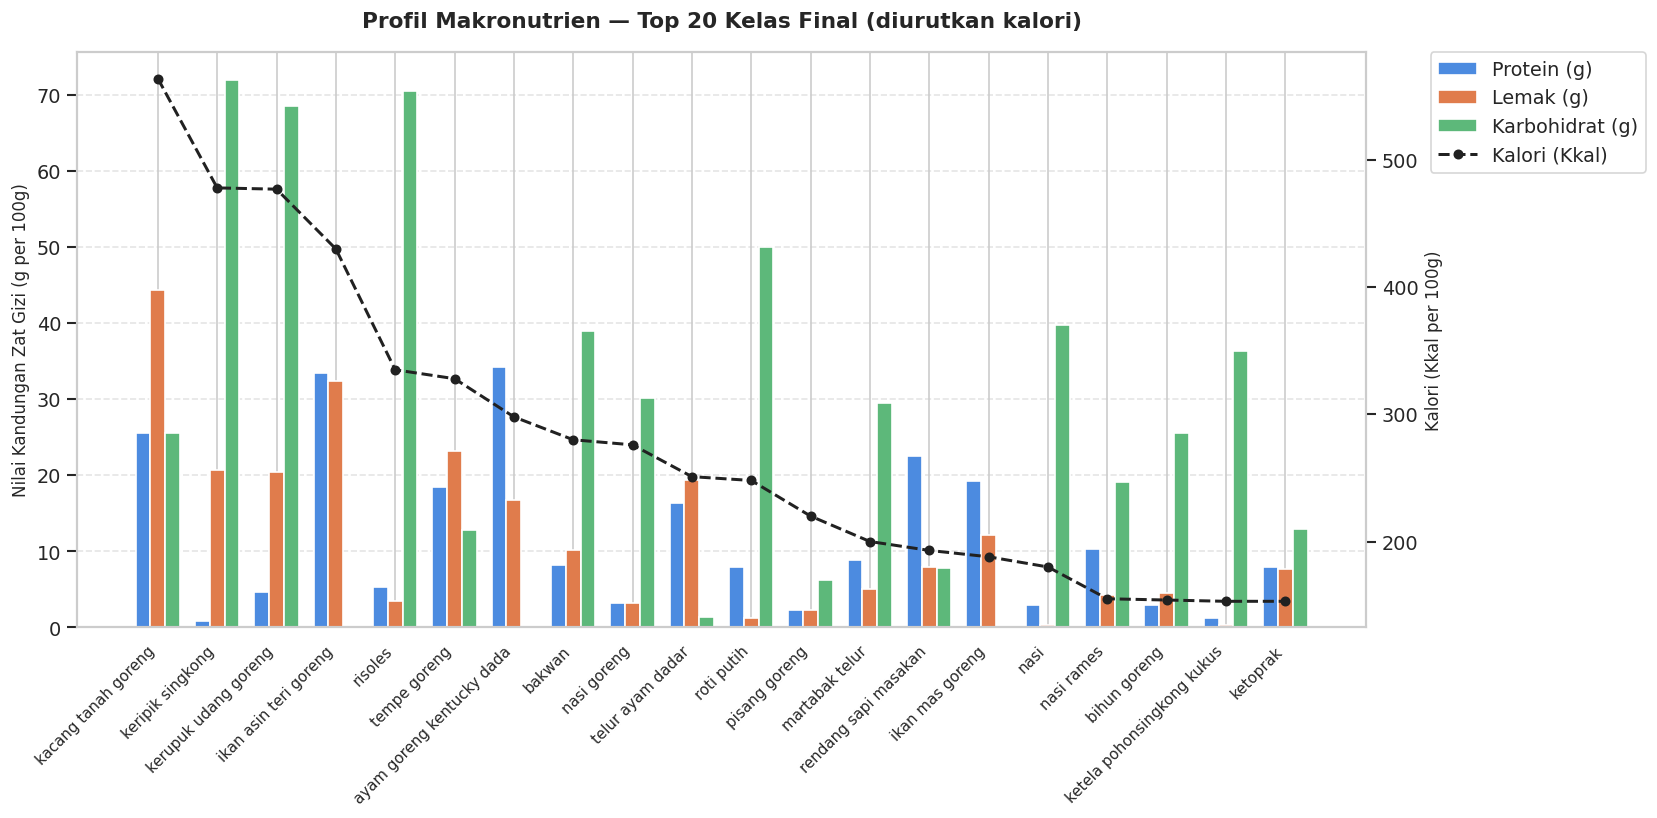

In [30]:
# Visualisasi Profil Nutrisi Kelas Final (Top 20 berdasarkan kalori)
df_viz = df_selected.dropna(subset=['kalori','protein','lemak','karbohidrat'])
df_viz = df_viz.sort_values('kalori', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(df_viz))
width = 0.25

bars_p = ax.bar(x - width, df_viz['protein'].values,      width, label='Protein (g)',     color='#4C8BE0')
bars_l = ax.bar(x,          df_viz['lemak'].values,        width, label='Lemak (g)',       color='#E07C4C')
bars_k = ax.bar(x + width,  df_viz['karbohidrat'].values,  width, label='Karbohidrat (g)', color='#5DB87A')

ax.set_xticks(x)
ax.set_xticklabels(df_viz['nama_makanan'].values, rotation=45, ha='right', fontsize=9)
ax.set_title('Profil Makronutrien — Top 20 Kelas Final (diurutkan kalori)', fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Nilai Kandungan Zat Gizi (g per 100g)', fontsize=10)

ax2 = ax.twinx()
line_cal = ax2.plot(x, df_viz['kalori'].values, 'k--o', markersize=5, linewidth=1.8, label='Kalori (Kkal)', color='#212121')
ax2.set_ylabel('Kalori (Kkal per 100g)', fontsize=10)
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0)
ax2.grid(False)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Berdasarkan grafik gabungan (*dual-axis chart*) di atas, visualisasi menyajikan perbandingan komparatif yang jelas antara kandungan zat gizi makro (batang) dan total energi (garis putus-putus) dari 20 makanan kelas final yang diurutkan dari kalori tertinggi ke terendah. Tren utama menunjukkan bahwa lonjakan energi (kalori) di batas atas dikomandani secara mutlak oleh kombinasi makanan tinggi lemak dan teknik pengolahan goreng, seperti yang terlihat pada **kacang tanah goreng** yang memuncaki grafik dengan energi mendekati 600 Kkal akibat tingginya konsentrasi komponen lemak. Di sisi lain, rumpun makanan pokok dan camilan tradisional seperti **keripik singkong**, **kerupuk udang goreng**, dan **risoles** menunjukkan karakteristik kepadatan kalori yang tinggi akibat dominasi kandungan karbohidrat masif yang berpadu dengan retensi minyak pasca-penggorengan.

Sebaliknya, saat bergeser ke arah kanan grafik di mana tren garis kalori menurun secara linier, struktur makronutrien mulai didominasi oleh makanan dengan kandungan air lebih tinggi atau yang tidak melewati proses penggorengan ekstrem. Komoditas seperti **rendang sapi masakan** dan **ayam goreng kentucky dada** menonjol sebagai sumber protein hewani murni yang efisien karena mempertahankan tinggi batang biru (protein) yang substansial di tengah tingkat kalori yang mulai melandai moderat. Sementara itu, makanan seperti **nasi**, **bihun goreng**, dan **ketela pohon/singkong kukus** mengelompok di area batas bawah energi (di bawah 200 Kkal) dengan profil yang hampir murni diisi oleh karbohidrat (batang hijau) tanpa membawa muatan lemak bebas yang berarti. Pola distribusi multivariat ini menegaskan bahwa untuk klasifikasi objek gambar berbasis nutrisi, fitur interaksi antara tinggi batang lemak dan karbohidrat memegang peranan krusial sebagai prediktor utama penentu estimasi total kalori suatu hidangan.

---
## 8. Export Dataset

Menyimpan tiga file output:
- `df_merged.csv` — seluruh data gabungan sebelum deduplikasi
- `df_food.csv` — dataset bersih dengan fitur turunan
- `df_selected_classes.csv` — ~50 kelas final beserta nutrisi lengkap

In [31]:
# Simpan ke CSV
df_merged.to_csv('df_merged.csv', index=False)
df_food.to_csv('df_food.csv', index=False)
df_selected.to_csv('df_selected_classes.csv', index=False)

print("File berhasil disimpan:")
print(f"   df_merged.csv            → {len(df_merged):,} baris")
print(f"   df_food.csv              → {len(df_food):,} baris")
print(f"   df_selected_classes.csv  → {len(df_selected):,} baris")

File berhasil disimpan:
   df_merged.csv            → 2,494 baris
   df_food.csv              → 1,634 baris
   df_selected_classes.csv  → 45 baris


In [32]:
# Cek info data df_food
print("=" * 50)
print("Struktur df_food Saat Ini (df.info())")
print("=" * 50)
df_food.info()
print("\n" + "=" * 50)

Struktur df_food Saat Ini (df.info())
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1634 entries, 0 to 1633
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   1634 non-null   int64  
 1   jenis_makanan        1634 non-null   object 
 2   nama_makanan         1634 non-null   object 
 3   kalori               1634 non-null   float64
 4   protein              1634 non-null   float64
 5   lemak                1634 non-null   float64
 6   karbohidrat          1634 non-null   float64
 7   source               1634 non-null   object 
 8   protein_per_calorie  1634 non-null   float64
 9   fat_per_calorie      1634 non-null   float64
 10  carb_per_calorie     1634 non-null   float64
 11  protein_fat_ratio    1634 non-null   float64
 12  macro_balance_score  1634 non-null   float64
dtypes: float64(9), int64(1), object(3)
memory usage: 166.1+ KB



## Data Dictionary — df_food.csv

Dokumentasi ini menjelaskan struktur, tipe data, dan definisi operasional dari setiap kolom di dalam dataset `df_food.csv` setelah melalui tahapan data cleaning dan feature engineering.

| # | Nama Kolom | Tipe Data | Deskripsi |
|---|------------|-----------|-----------|
| 1 | `id` | `int64` | Identifier unik untuk setiap baris entri bahan makanan atau hidangan. |
| 2 | `jenis_makanan` | `object` | Kategori makanan, diklasifikasikan menjadi **dish** (makanan siap konsumsi/olahan campuran) atau **komponen** (bahan mentah/tunggal). |
| 3 | `nama_makanan` | `object` | Nama makanan atau hidangan yang telah dinormalisasi (huruf kecil, tanpa tanda baca, dan spasi ganda dihapus). |
| 4 | `kalori` | `float64` | Kandungan energi total per 100 gram bahan makanan, dinyatakan dalam satuan Kalori ($Kal$ atau $kcal$). |
| 5 | `protein` | `float64` | Kandungan protein per 100 gram bahan makanan, dinyatakan dalam satuan gram ($g$). |
| 6 | `lemak` | `float64` | Kandungan lemak total per 100 gram bahan makanan, dinyatakan dalam satuan gram ($g$). |
| 7 | `karbohidrat` | `float64` | Kandungan karbohidrat total per 100 gram bahan makanan, dinyatakan dalam satuan gram ($g$). |
| 8 | `source` | `object` | Sumber dataset asal sebelum digabungkan, bernilai `'tkpi'` (Tabel Komposisi Pangan Indonesia) atau `'kaggle'`. |
| 9 | `protein_per_calorie`| `float64` | Rasio kandungan protein terhadap total kalori ($\frac{\text{protein}}{\text{kalori}}$) per gram. Menunjukkan densitas/efisiensi protein suatu makanan. |
| 10 | `fat_per_calorie` | `float64` | Rasio kandungan lemak terhadap total kalori ($\frac{\text{lemak}}{\text{kalori}}$) per gram. Menunjukkan densitas lemak suatu makanan. |
| 11 | `carb_per_calorie` | `float64` | Rasio kandungan karbohidrat terhadap total kalori ($\frac{\text{karbohidrat}}{\text{kalori}}$) per gram. Menunjukkan densitas karbohidrat suatu makanan. |
| 12 | `protein_fat_ratio` | `float64` | Perbandingan langsung antara kadar protein terhadap lemak ($\frac{\text{protein}}{\text{lemak}}$). Berguna untuk analisis diet tinggi protein rendah lemak. |
| 13 | `macro_balance_score`| `float64` | Skor kalkulasi hasil *feature engineering* yang menunjukkan tingkat keseimbangan distribusi proporsi energi dari ketiga zat gizi makro. |

In [33]:
# Mendefinisikan struktur data dictionary
data_dict_structure = {
    "Nama Kolom": [
        "id", "jenis_makanan", "nama_makanan", "kalori", "protein", "lemak", "karbohidrat",
        "source", "protein_per_calorie", "fat_per_calorie", "carb_per_calorie",
        "protein_fat_ratio", "macro_balance_score"
    ],
    "Tipe Data": [
        "int64", "object", "object", "float64", "float64", "float64", "float64",
        "object", "float64", "float64", "float64", "float64", "float64"
    ],
    "Deskripsi": [
        "Identifier unik untuk setiap entri bahan makanan atau hidangan.",
        "Kategori makanan, dipisahkan menjadi 'dish' (makanan siap konsumsi) atau 'komponen' (bahan mentah/tunggal).",
        "Nama bahan makanan atau hidangan yang sudah melewati proses normalisasi teks (lowercase, tanpa tanda baca).",
        "Kandungan energi total per 100 gram bahan makanan, dinyatakan dalam satuan Kalori (Kal/kcal).",
        "Kandungan protein per 100 gram bahan makanan, dinyatakan dalam satuan gram (g).",
        "Kandungan lemak total per 100 gram bahan makanan, dinyatakan dalam satuan gram (g).",
        "Kandungan karbohidrat total per 100 gram bahan makanan, dinyatakan dalam satuan gram (g).",
        "Sumber asal data operasional, mengindikasikan apakah data berasal dari 'tkpi' atau 'kaggle'.",
        "Rasio kandungan protein terhadap total kalori (g/Kal), digunakan untuk mengukur efisiensi densitas protein.",
        "Rasio kandungan lemak terhadap total kalori (g/Kal), digunakan untuk mengukur densitas lemak.",
        "Rasio kandungan karbohidrat terhadap total kalori (g/Kal), digunakan untuk mengukur densitas karbohidrat.",
        "Perbandingan antara total protein terhadap total lemak (protein dibagi lemak) dalam suatu makanan.",
        "Skor kalkulasi hasil feature engineering yang menunjukkan tingkat keseimbangan proporsi zat gizi makro."
    ]
}

df_dictionary = pd.DataFrame(data_dict_structure)

# Simpan ke dalam format CSV
df_dictionary.to_csv("data_dictionary_df_food.csv", index=False)

# Simpan ke dalam format Markdown (.md)
markdown_template = """# Data Dictionary - df_food.csv

Berikut adalah dokumentasi skema kolom untuk file `df_food.csv` data nutrisi makanan Indonesia:

| # | Nama Kolom | Tipe Data | Deskripsi |
|---|------------|-----------|-----------|
"""

for idx, row in df_dictionary.iterrows():
    markdown_template += f"| {idx+1} | `{row['Nama Kolom']}` | `{row['Tipe Data']}` | {row['Deskripsi']} |\n"

with open("data_dictionary_df_food.md", "w", encoding="utf-8") as f:
    f.write(markdown_template)

print("File Data Dictionary berhasil dibuat:")
print("   - data_dictionary_df_food.csv (Format Tabel Data)")
print("   - data_dictionary_df_food.md  (Format Dokumentasi Markdown)")

File Data Dictionary berhasil dibuat:
   - data_dictionary_df_food.csv (Format Tabel Data)
   - data_dictionary_df_food.md  (Format Dokumentasi Markdown)
